In [1]:
import sys
sys.path.append("../")
from src.simulation.firm import * # custom firm code
from src.simulation.gaussian_process import * # custom GP code

import matplotlib.pyplot as plt

In [2]:
def plot_firm_diagnostics(
    K, I, T, p, env, rational_agent, firm_agents, k_ss, b_ss,
    n_firms=5,
    percentiles=None,
    firm_ids=None,
    k_xlim=(0, 25),
    smooth_window=31,
    smooth_window_ts=11,
    title_suffix=""
):
    from scipy.signal import savgol_filter
    from scipy.interpolate import interp1d

    def smooth(y, window=smooth_window, poly=3):
        if len(y) < window:
            return y
        return savgol_filter(y, window, poly)

    def smooth_ts(y):
        return smooth(y, window=smooth_window_ts, poly=2)

    k_terminal = K[:, -1]
    N_FIRMS = K.shape[0]

    if firm_ids is None:
        if percentiles is None:
            percentiles = np.linspace(5, 95, n_firms).astype(int).tolist()
        firm_ids = [int(np.argmin(np.abs(k_terminal - np.percentile(k_terminal, pct))))
                    for pct in percentiles]

    n_plot = len(firm_ids)

    # Distinct colors for firms — avoid grays/blacks (reserved for reference lines)
    firm_colors = ['#1f77b4', '#d62728', '#ff7f0e', '#2ca02c', '#9467bd',
                   '#8c564b', '#e377c2', '#17becf', '#bcbd22', '#7f7f7f']
    colors = [firm_colors[i % len(firm_colors)] for i in range(n_plot)]
    labels = [f'Firm {j} (k̄={k_terminal[j]:.1f})' for j in firm_ids]

    print(f"Selected {n_plot} firms:")
    for j, lab in zip(firm_ids, labels):
        print(f"  {lab}")

    selected_agents = [firm_agents[j] for j in firm_ids]
    selected_K = [K[j, :] for j in firm_ids]
    selected_I = [I[j, :] for j in firm_ids]

    k_eval = np.linspace(p.K_min + 0.1, k_xlim[1], 300)
    kp_rat_curve = np.array([rational_agent.policy(1.0, k)[0] for k in k_eval])

    iz_idx = int(np.argmin(np.abs(rational_agent.z_grid - 1.0)))
    v_rat_interp = interp1d(rational_agent.k_grid, rational_agent.v[iz_idx, :],
                             kind='cubic', fill_value='extrapolate')

    max_kp_raw = []
    for k in k_eval:
        b = env.optimal_b_next(k)
        valid_k, _, _ = selected_agents[0]._get_action_queries(1.0, k, b)
        max_kp_raw.append(valid_k[-1] if len(valid_k) > 0 else k)
    max_kp_interp = interp1d(k_eval, max_kp_raw, kind='cubic', fill_value='extrapolate')
    max_kp = max_kp_interp(k_eval)

    # Precompute expected policies for reuse
    all_kp_exp = []
    for agent_j in selected_agents:
        kp_exp = np.array([
            agent_j.get_expected_action(1.0, k, env.optimal_b_next(k))[0]
            for k in k_eval
        ])
        all_kp_exp.append(kp_exp)

    # ── Helper to draw reference lines on a policy plot ──
    def draw_policy_refs(ax, xlim, ylim):
        ax.plot(k_eval, k_eval, color='gray', ls='--', alpha=0.4, lw=1.5, label='45° line')
        ax.plot(k_eval, smooth(kp_rat_curve), 'k-', lw=2.5, label='Rational π*(k)')
        ax.plot(k_eval, (1 - p.DELTA) * np.array(k_eval),
                color='silver', ls=':', lw=1.5, label="k'=(1-δ)k")
        ax.plot(k_eval, max_kp, color='lightgray', ls='--', lw=1.5, label="Max k' (d≥0)")
        ax.axvline(k_ss, color='gray', ls=':', alpha=0.4)
        ax.scatter([k_ss], [k_ss], color='red', s=80, zorder=5)
        ax.set_xlim(*xlim); ax.set_ylim(*ylim)

    fig, axes = plt.subplots(2, 4, figsize=(32, 14))

    # ── 1. Capital paths ──
    ax = axes[0, 0]
    for k_path, c, lab in zip(selected_K, colors, labels):
        ax.plot(smooth_ts(k_path), color=c, lw=1.5, label=lab)
    ax.axhline(k_ss, color='gray', ls='--', lw=2, alpha=0.5, label=f'k*={k_ss:.2f}')
    ax.set_xlabel('t'); ax.set_ylabel('k')
    ax.set_title('Capital Paths')
    ax.legend(fontsize=6); ax.grid(True, alpha=0.2)

    # ── 2. Expected policy E[k'|k] — full range ──
    ax = axes[0, 1]
    draw_policy_refs(ax, k_xlim, k_xlim)
    for kp_exp, c, lab in zip(all_kp_exp, colors, labels):
        ax.plot(k_eval, smooth(kp_exp), color=c, lw=2, label=lab)
    ax.set_xlabel('k'); ax.set_ylabel("E[k'|k]")
    ax.set_title("Learned Policy E[k'|k] at z=1")
    ax.legend(fontsize=6); ax.grid(True, alpha=0.2)

    # ── 3. Expected policy — ZOOMED around k* ──
    ax = axes[0, 2]
    zoom = 5
    zoom_lim = (max(k_ss - zoom, p.K_min + 0.1), k_ss + zoom)
    draw_policy_refs(ax, zoom_lim, zoom_lim)
    for kp_exp, c, lab in zip(all_kp_exp, colors, labels):
        ax.plot(k_eval, smooth(kp_exp), color=c, lw=2, label=lab)
    ax.set_xlabel('k'); ax.set_ylabel("E[k'|k]")
    ax.set_title(f"Policy ZOOM: k* ± {zoom}")
    ax.legend(fontsize=6); ax.grid(True, alpha=0.2)

    # ── 4. Learned value function vs rational V* ──
    ax = axes[0, 3]
    ax.plot(k_eval, v_rat_interp(k_eval), 'k-', lw=2.5, label='Rational V*(k)')
    for agent_j, c, lab in zip(selected_agents, colors, labels):
        v_learned = np.array([
            agent_j.gp.predict(
                np.array([[1.0, k,
                    agent_j.get_expected_action(1.0, k, env.optimal_b_next(k))[0]
                    - (1.0 - p.DELTA) * k]]),
                return_std=False
            )[0]
            for k in k_eval
        ])
        ax.plot(k_eval, smooth(v_learned), color=c, lw=2, label=lab)
    ax.set_xlabel('k'); ax.set_ylabel('V(k)')
    ax.set_title('Learned Q*(k, E[i]) vs Rational V*(k)')
    ax.legend(fontsize=6); ax.grid(True, alpha=0.2)

    # ── 5. GP posterior uncertainty ──
    ax = axes[1, 0]
    for agent_j, c, lab in zip(selected_agents, colors, labels):
        stds = np.array([
            agent_j.gp.predict(
                np.array([[1.0, k,
                    agent_j.get_expected_action(1.0, k, env.optimal_b_next(k))[0]
                    - (1.0 - p.DELTA) * k]]),
                return_std=True
            )[1][0]
            for k in k_eval
        ])
        ax.plot(k_eval, smooth(stds), color=c, lw=2, label=lab)
    ax.axvline(k_ss, color='gray', ls=':', alpha=0.4, label=f'k*={k_ss:.2f}')
    ax.set_xlabel('k'); ax.set_ylabel('σ(k)')
    ax.set_title('GP Posterior Uncertainty σ(k) at z=1')
    ax.legend(fontsize=6); ax.grid(True, alpha=0.2)

    # ── 6. Investment rate i/k ──
    ax = axes[1, 1]
    for k_path, i_path, c, lab in zip(selected_K, selected_I, colors, labels):
        ik = i_path / np.maximum(k_path, 1e-8)
        ax.plot(smooth_ts(ik), color=c, lw=1.5, alpha=0.8, label=lab)
    ax.axhline(p.DELTA, color='gray', ls='--', lw=2, alpha=0.5, label=f'δ={p.DELTA}')
    ax.axhline(0, color='black', ls=':', alpha=0.2)
    ax.set_xlabel('t'); ax.set_ylabel('i/k')
    ax.set_title('Investment Rate')
    ax.legend(fontsize=6); ax.grid(True, alpha=0.2)

    # ── 7. Terminal k distribution ──
    ax = axes[1, 2]
    ax.hist(k_terminal, bins=40, density=True, alpha=0.5, color='lightgray',
            edgecolor='gray', label='All firms')
    for j, c, lab in zip(firm_ids, colors, labels):
        ax.axvline(k_terminal[j], color=c, lw=2, label=lab)
    ax.axvline(k_ss, color='black', ls='--', lw=2, label=f'k*={k_ss:.2f}')
    ax.set_xlabel('Terminal k'); ax.set_ylabel('Density')
    ax.set_title('Cross-Sectional Distribution of k̄')
    ax.legend(fontsize=6); ax.grid(True, alpha=0.2)

    # ── 8. Mean K over time: experience vs rational ──
    ax = axes[1, 3]
    ax.plot(K.mean(axis=0), color='#1f77b4', lw=2, label='Experience (mean)')
    ax.fill_between(range(T),
                     np.percentile(K, 25, axis=0),
                     np.percentile(K, 75, axis=0),
                     color='#1f77b4', alpha=0.15, label='IQR')
    from scipy.interpolate import interp1d as _interp  # avoid shadowing
    K_RAT_mean = np.array([rational_agent.policy(1.0, k_ss)[0]] * T)  # constant at k* for reference
    ax.axhline(k_ss, color='black', ls='--', lw=2, label=f'k*={k_ss:.2f}')
    ax.set_xlabel('t'); ax.set_ylabel('k')
    ax.set_title('Mean Capital Over Time')
    ax.legend(fontsize=6); ax.grid(True, alpha=0.2)

    suptitle = f'{n_plot} Firms: Policies, Values & Paths ({N_FIRMS} total, T={T})'
    if title_suffix:
        suptitle += f' — {title_suffix}'
    plt.suptitle(suptitle, fontsize=14)
    plt.tight_layout()
    plt.show()

    return selected_agents, firm_ids

## TEST - Experience Agent With Prior Set on Rational Policy [NO SHOCKS, NO EXPLORATION]

Under this test the Experienced Based Agent should immediately find the rational policy and stick to it

/Users/adamcostarino/Repositories/independent_study_cosmin_ilut/scripts/../src/simulation/firm.py:271: UserWarning: Zero volatility or zero z states: using degenerate z grid with a single point at 1.0.
  warnings.warn("Zero volatility or zero z states: using degenerate z grid with a single point at 1.0.")


k* = 10.3030
Final k: mean=10.3030  std=0.000000
Max |k - k*| = 0.000002
Selected 5 firms:
  Firm 0 (k̄=10.3)
  Firm 2 (k̄=10.3)
  Firm 4 (k̄=10.3)
  Firm 6 (k̄=10.3)
  Firm 8 (k̄=10.3)


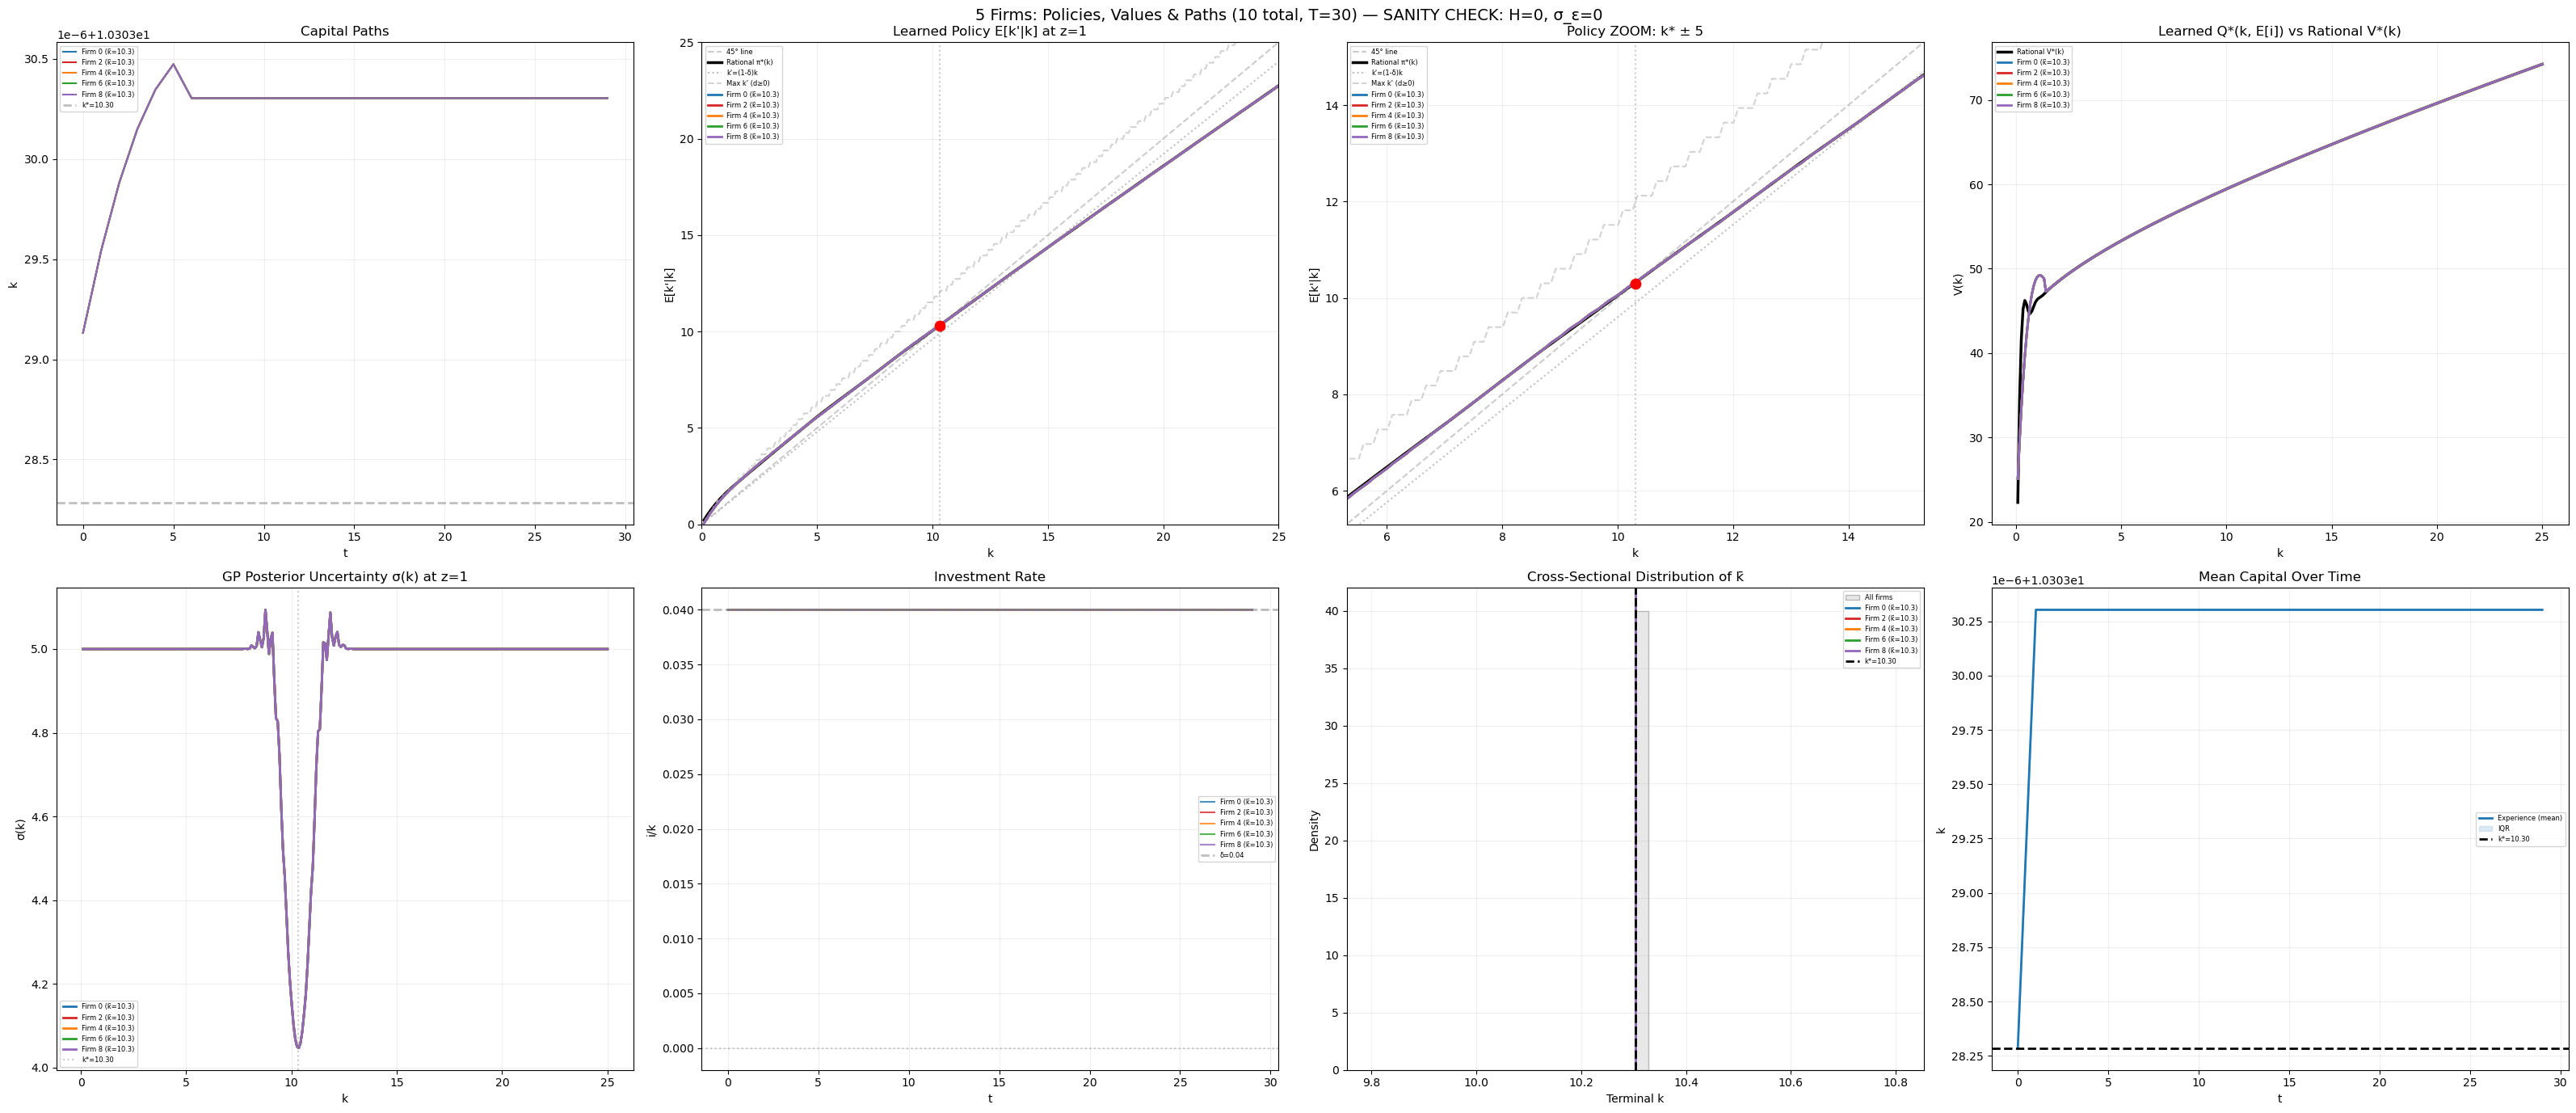

([<src.simulation.firm.ExperienceAgent at 0x32506c1d0>,
 [0, 2, 4, 6, 8])

In [ ]:
import numpy as np

p_test = InvestmentParameters(KAPPA=2.0, SIGMA_EPS=0.0, RHO=0.0, DELTA=0.04,
                               R=0.01, N_z=0, BETA=0.97, THETA=0.3,
                               K_min=0.0, K_max=30)
env_test = InvestmentEnvironment(p_test, QuadraticAdjustmentCosts(p_test.KAPPA), seed=42)
rat_test = RationalInvestmentAgent(env_test).fit()
k_ss_test = rat_test.fixed_point()
b_ss_test = env_test.optimal_b_next(k_ss_test)

kernel = RBFKernel(sigma0=5.0, length_scales=[1.0, 0.6061, 0.0707])
gp_params_test = GPBeliefParameters(kernel=kernel, sigma_n=0.01)
prior_test = TrueValueFunctionPrior(rat_test)

N_TEST = 10
T_TEST = 30

K_TEST = np.zeros((N_TEST, T_TEST))
I_TEST = np.zeros((N_TEST, T_TEST))
test_agents = []

for j in range(N_TEST):
    gp_j = GPBelief(env_params=p_test, gp_params=gp_params_test, prior_mean_fn=prior_test)
    agent_j = ExperienceReasoningAgent(env=env_test, gp=gp_j,
                               agent_params=InvestmentAgentParameters(H=0.0), seed=j)
    z_t, k_t, b_t = 1.0, k_ss_test, b_ss_test

    for t in range(T_TEST):
        kp_t, b_next = agent_j.get_greedy_action(1.0, k_t, b_t)
        i_t = kp_t - (1.0 - p_test.DELTA) * k_t
        gp_obs = env_test.gp_observation(1.0, k_t, i_t, b_next)

        kp_greedy, _ = agent_j.get_greedy_action(1.0, kp_t, b_next)
        i_greedy = kp_greedy - (1.0 - p_test.DELTA) * kp_t
        agent_j.gp.add_observation(
            np.array([1.0, k_t, i_t]),
            np.array([1.0, kp_t, i_greedy]),
            gp_obs
        )

        K_TEST[j, t] = k_t
        I_TEST[j, t] = i_t
        k_t, b_t = kp_t, b_next

    test_agents.append(agent_j)

k_final = K_TEST[:, -1]
print(f"k* = {k_ss_test:.4f}")
print(f"Final k: mean={k_final.mean():.4f}  std={k_final.std():.6f}")
print(f"Max |k - k*| = {np.max(np.abs(k_final - k_ss_test)):.6f}")

# ── Plot ──
plot_firm_diagnostics(
    K_TEST, I_TEST, T_TEST, p_test, env_test, rat_test,
    test_agents, k_ss_test, b_ss_test,
    firm_ids=[0, 2, 4, 6, 8], k_xlim=(0, 25),
    title_suffix="SANITY CHECK: H=0, σ_ε=0"
)

## TEST - Experience Agent With Prior Set on Rational Policy [NO SHOCKS, WITH EXPLORATION]

Under this test the Experienced Based Agent should explore but eventually find and converge
to the optimal policy if the GP prior is programmed correctly. We simulate 30 agents.

/Users/adamcostarino/Repositories/independent_study_cosmin_ilut/scripts/../src/simulation/firm.py:271: UserWarning: Zero volatility or zero z states: using degenerate z grid with a single point at 1.0.
  warnings.warn("Zero volatility or zero z states: using degenerate z grid with a single point at 1.0.")


k* = 10.3030
Final k: mean=10.3030  std=0.000000
Max |k - k*| = 0.000002
Selected 5 firms:
  Firm 0 (k̄=10.3)
  Firm 2 (k̄=10.3)
  Firm 4 (k̄=10.3)
  Firm 6 (k̄=10.3)
  Firm 8 (k̄=10.3)


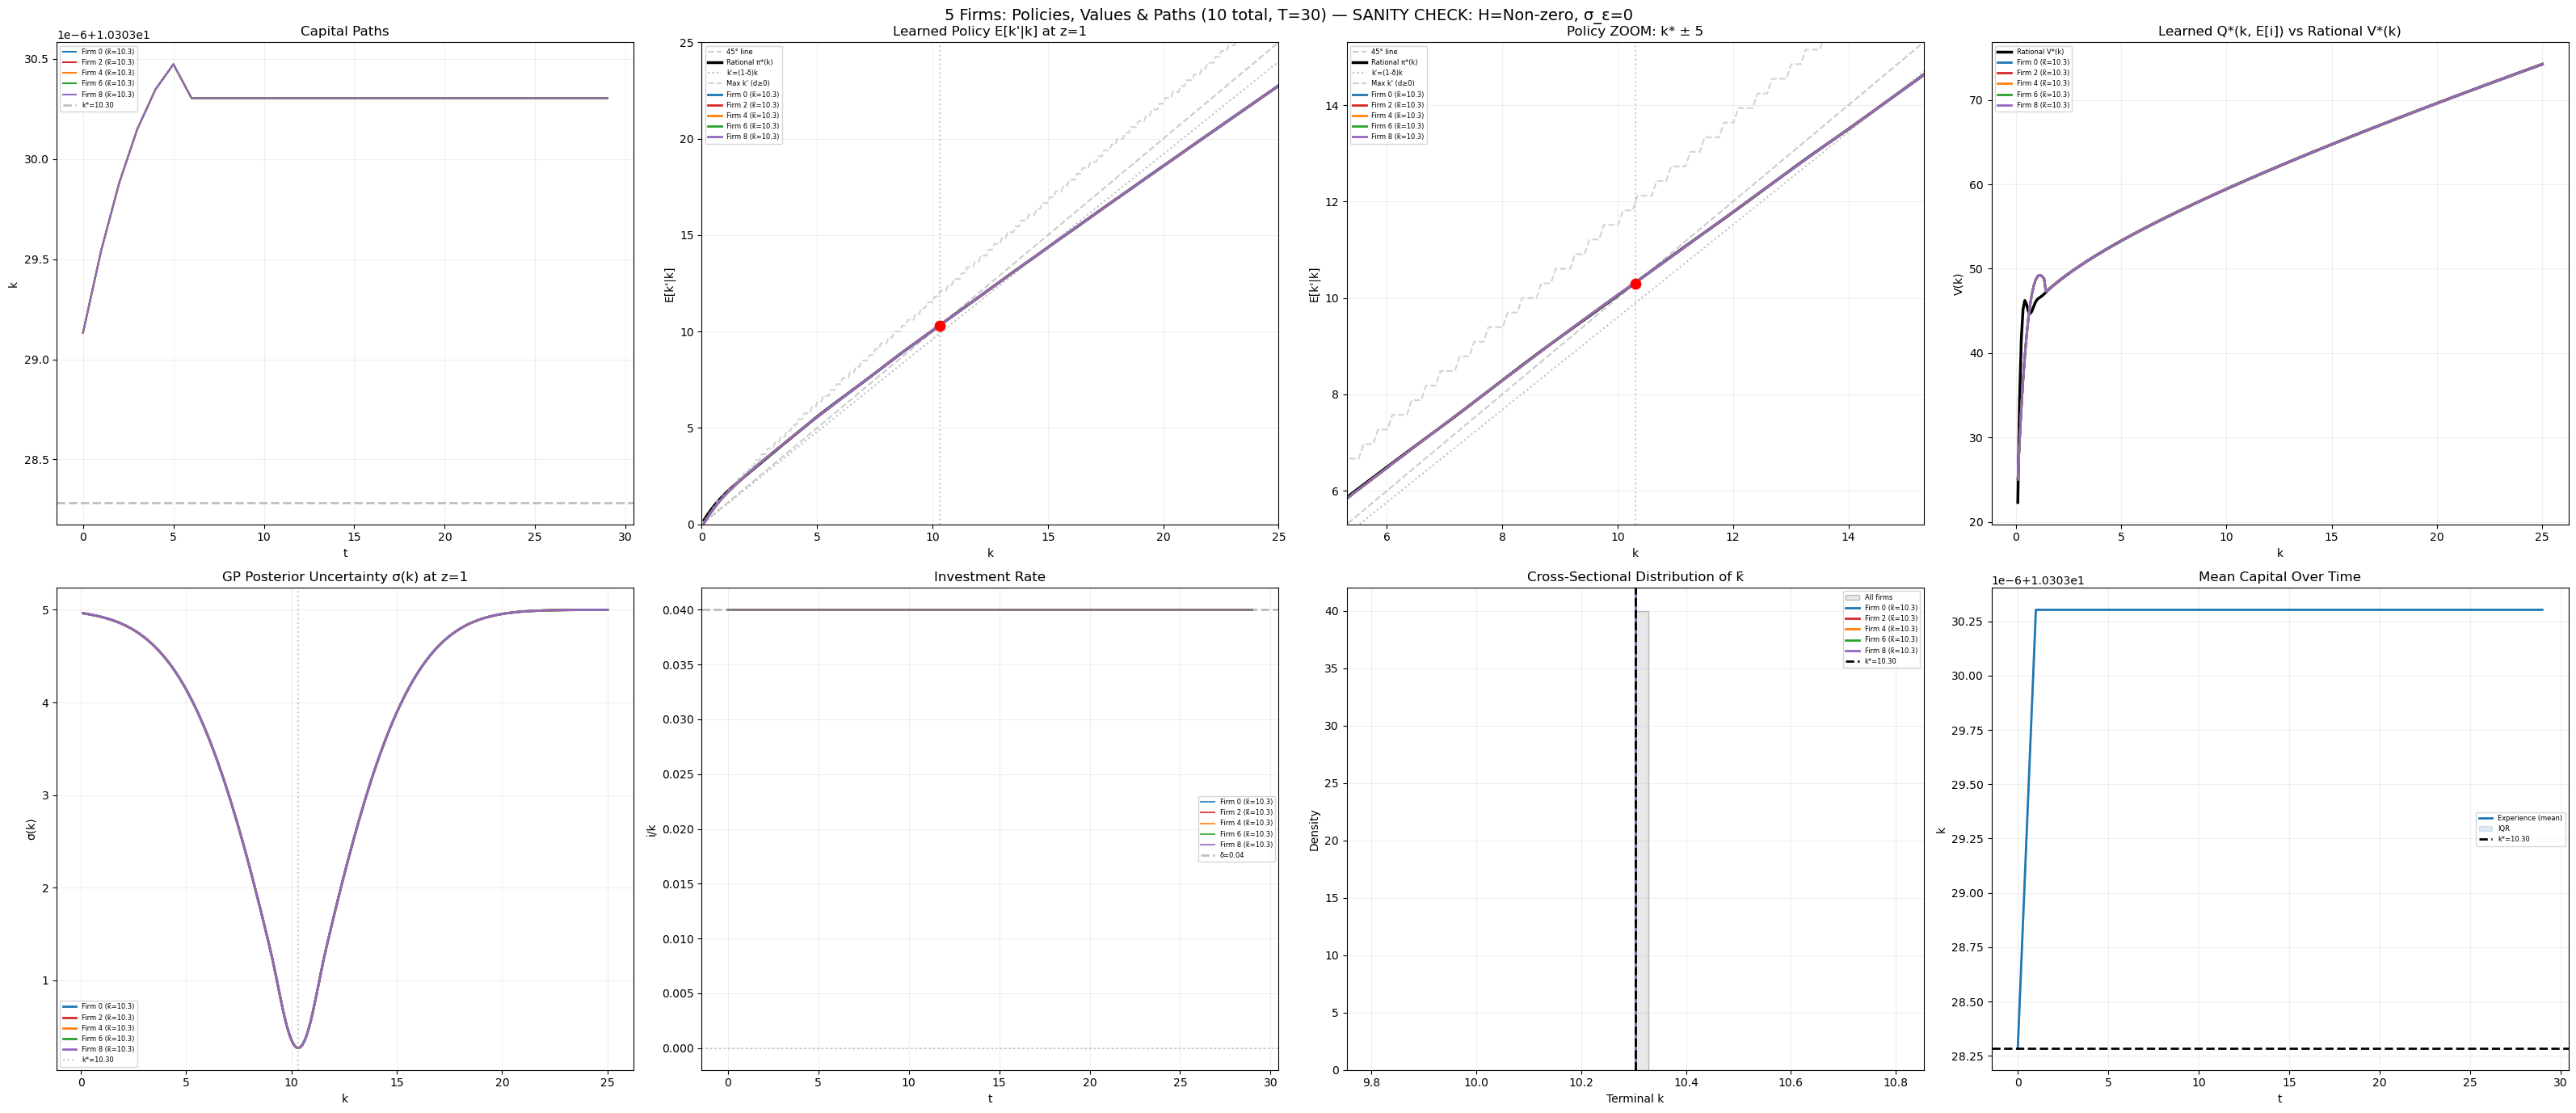

([<src.simulation.firm.ExperienceAgent at 0x324e3f560>,
 [0, 2, 4, 6, 8])

In [ ]:
import numpy as np

p_test = InvestmentParameters(KAPPA=2.0, SIGMA_EPS=0.0, RHO=0.0, DELTA=0.04,
                               R=0.01, N_z=0, BETA=0.97, THETA=0.3,
                               K_min=0.0, K_max=30)

env_test = InvestmentEnvironment(p_test, QuadraticAdjustmentCosts(p_test.KAPPA), seed=42)
rat_test = RationalInvestmentAgent(env_test).fit()
k_ss_test = rat_test.fixed_point()
b_ss_test = env_test.optimal_b_next(k_ss_test)

#gp_params_test = GPBeliefParameters(sigma0=5.0, lz=1.0, lk=5.0, li=2.0, sigma_n=0.01)
kernel = RBFKernel(sigma0=5.0, length_scales=[1.0, 5.0, 2.0])
gp_params_test = GPBeliefParameters(kernel=kernel, sigma_n=0.01)

prior_test = TrueValueFunctionPrior(rat_test)

N_TEST = 10
T_TEST = 30

K_TEST = np.zeros((N_TEST, T_TEST))
I_TEST = np.zeros((N_TEST, T_TEST))
test_agents = []

for j in range(N_TEST):
    gp_j = GPBelief(env_params=p_test, gp_params=gp_params_test, prior_mean_fn=prior_test)
    agent_j = ExperienceReasoningAgent(env=env_test, gp=gp_j,
                               agent_params=InvestmentAgentParameters(H=0.001), seed=j)
    z_t, k_t, b_t = 1.0, k_ss_test, b_ss_test

    for t in range(T_TEST):
        kp_t, b_next = agent_j.get_greedy_action(1.0, k_t, b_t)
        i_t = kp_t - (1.0 - p_test.DELTA) * k_t
        gp_obs = env_test.gp_observation(1.0, k_t, i_t, b_next)

        kp_greedy, _ = agent_j.get_greedy_action(1.0, kp_t, b_next)
        i_greedy = kp_greedy - (1.0 - p_test.DELTA) * kp_t
        agent_j.gp.add_observation(
            np.array([1.0, k_t, i_t]),
            np.array([1.0, kp_t, i_greedy]),
            gp_obs
        )

        K_TEST[j, t] = k_t
        I_TEST[j, t] = i_t
        k_t, b_t = kp_t, b_next

    test_agents.append(agent_j)

k_final = K_TEST[:, -1]
print(f"k* = {k_ss_test:.4f}")
print(f"Final k: mean={k_final.mean():.4f}  std={k_final.std():.6f}")
print(f"Max |k - k*| = {np.max(np.abs(k_final - k_ss_test)):.6f}")

# ── Plot ──
plot_firm_diagnostics(
    K_TEST, I_TEST, T_TEST, p_test, env_test, rat_test,
    test_agents, k_ss_test, b_ss_test,
    firm_ids=[0, 2, 4, 6, 8], k_xlim=(0, 25),
    title_suffix="SANITY CHECK: H=Non-zero, σ_ε=0"
)

## TEST - Experience Agent with One Negative shock at t=5 with T=50

/Users/adamcostarino/Repositories/independent_study_cosmin_ilut/scripts/../src/simulation/firm.py:271: UserWarning: Zero volatility or zero z states: using degenerate z grid with a single point at 1.0.
  warnings.warn("Zero volatility or zero z states: using degenerate z grid with a single point at 1.0.")


k* = 10.3030
Planned shock: -15% at t=5, ρ=0.9
Final: Exp k=1.82, Rat k=10.30, Δk=-8.48
Selected 1 firms:
  Firm 0 (k̄=1.5)


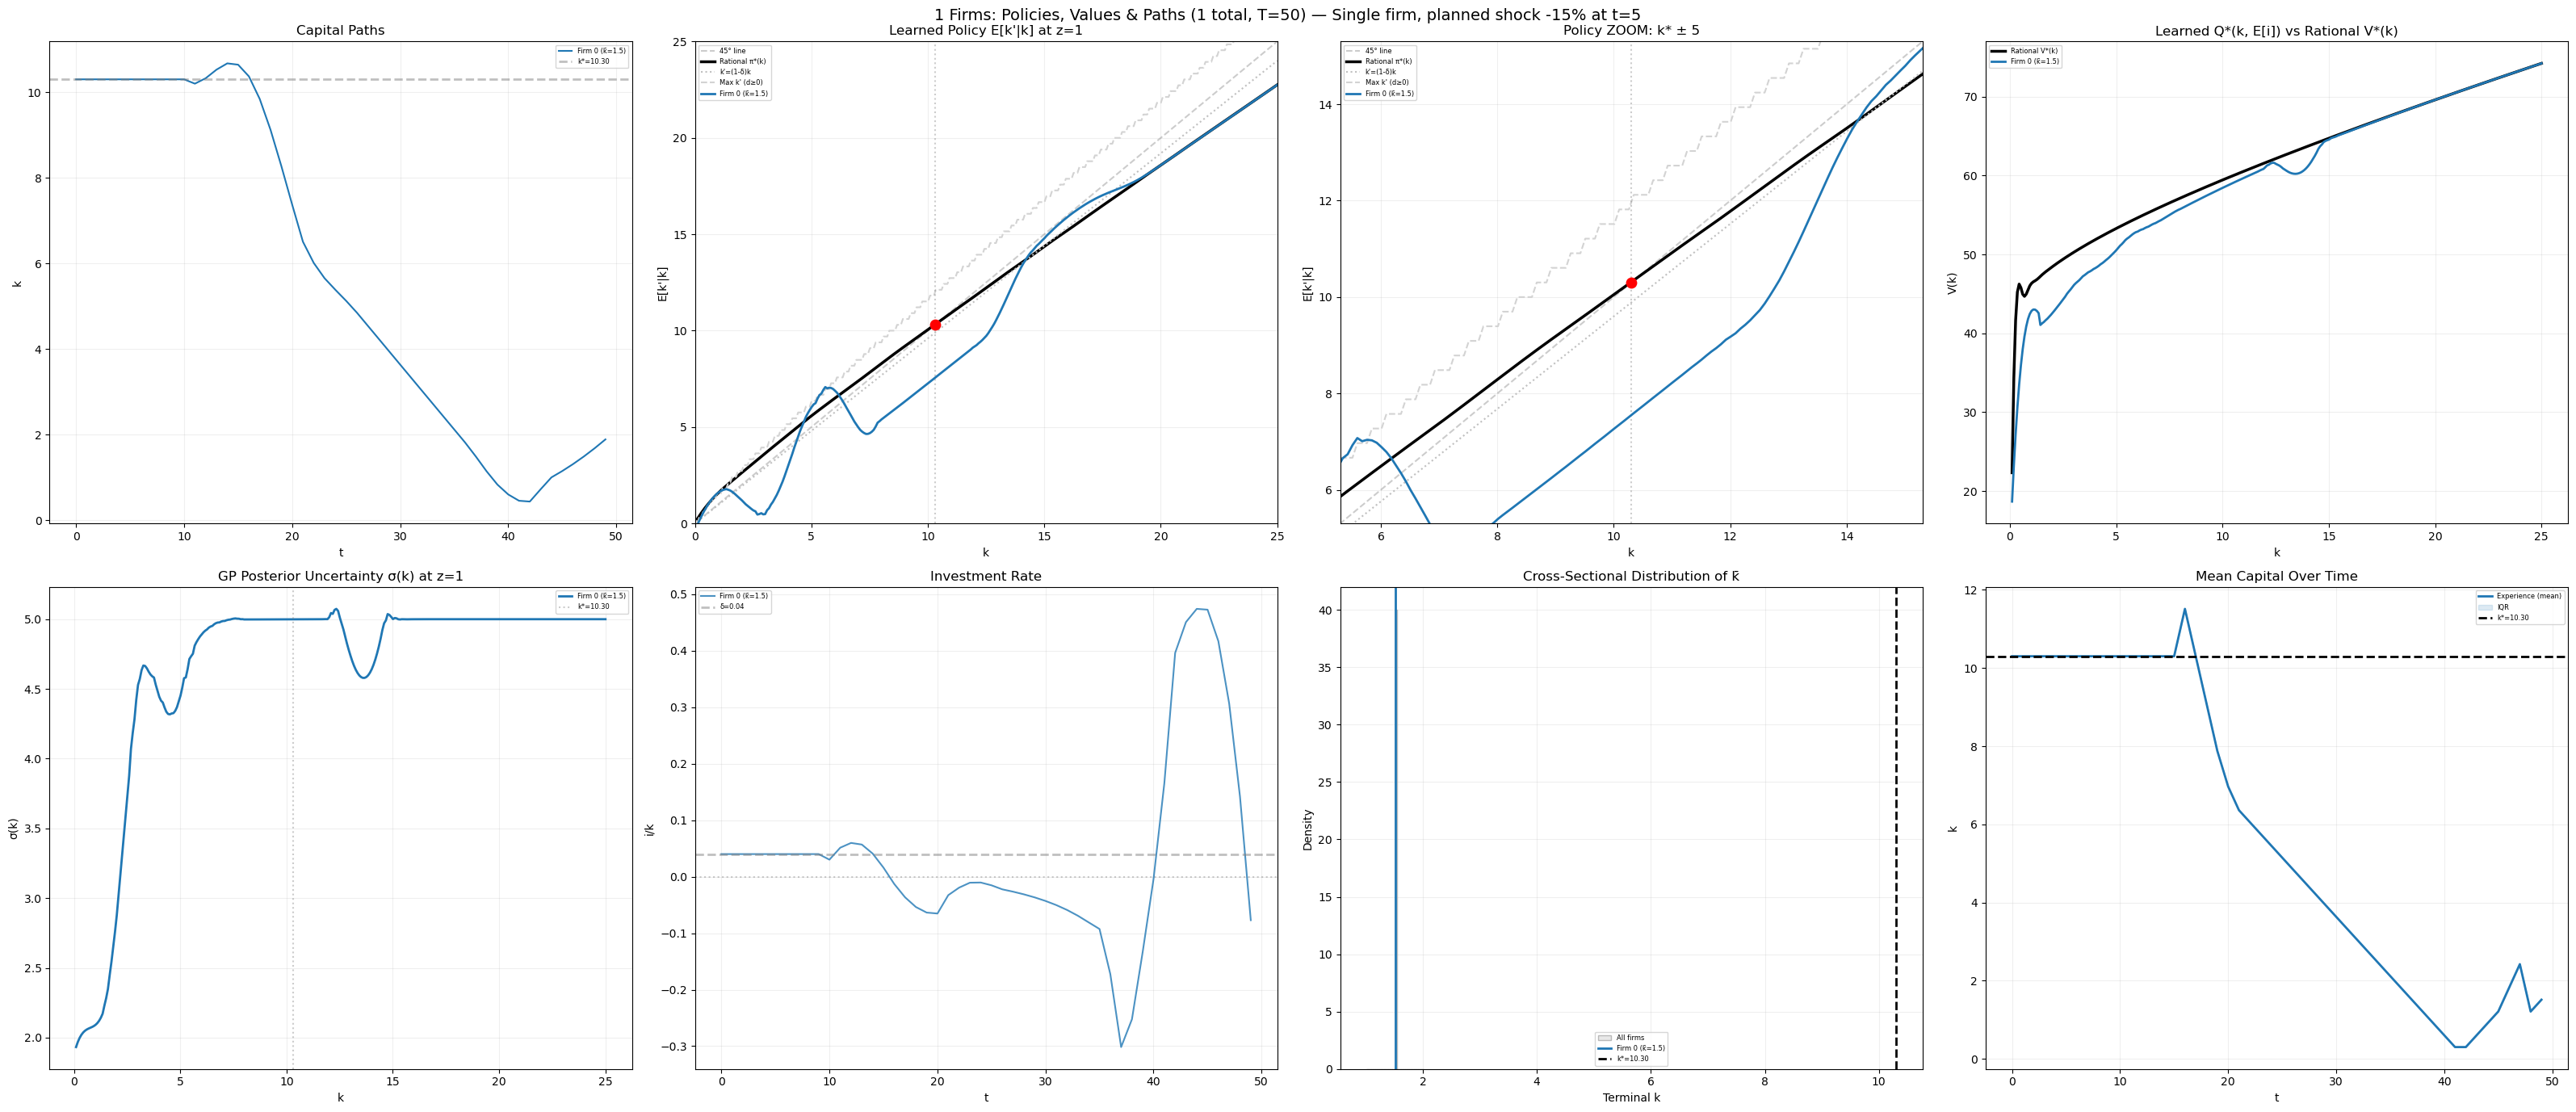

([<src.simulation.firm.ExperienceAgent at 0x3260736e0>], [0])

In [ ]:
import numpy as np
from scipy.interpolate import interp1d

# ── Setup ──
p = InvestmentParameters(KAPPA=2.0, SIGMA_EPS=0.0, RHO=0.9, DELTA=0.04,
                          R=0.01, N_z=5, BETA=0.97, THETA=0.3,
                          K_min=0.0, K_max=30)
env = InvestmentEnvironment(p, QuadraticAdjustmentCosts(p.KAPPA), seed=42)
rational_agent = RationalInvestmentAgent(env).fit()
k_ss = rational_agent.fixed_point()
b_ss = env.optimal_b_next(k_ss)

kernel = RBFKernel(sigma0=5.0, length_scales=[0.08, 2.0, 0.5])
gp_params = GPBeliefParameters(kernel=kernel, sigma_n=0.1)
true_value_prior = TrueValueFunctionPrior(rational_agent)

SHOCK_T = 5
SHOCK_SIZE = -0.15
N_FIRMS = 1
T = 50

K = np.zeros((N_FIRMS, T))
I = np.zeros((N_FIRMS, T))
D = np.zeros((N_FIRMS, T))
Z = np.zeros((N_FIRMS, T))
Q_CHOSEN = np.zeros((N_FIRMS, T))
K_RAT = np.zeros((N_FIRMS, T))
I_RAT = np.zeros((N_FIRMS, T))
D_RAT = np.zeros((N_FIRMS, T))
firm_agents = []

gp_j = GPBelief(env_params=p, gp_params=gp_params, prior_mean_fn=true_value_prior)
agent_j = ExperienceReasoningAgent(env=env, gp=gp_j,
                           agent_params=InvestmentAgentParameters(H=0.001), seed=0)

z_t, k_t, b_t = 1.0, k_ss, b_ss
z_rat, k_rat, b_rat = 1.0, k_ss, b_ss

print(f"k* = {k_ss:.4f}")
print(f"Planned shock: {SHOCK_SIZE:.0%} at t={SHOCK_T}, ρ={p.RHO}")

for t in range(T):
    # Deterministic z with planned shock
    if t == 0:
        z_common = 1.0
    elif t == SHOCK_T:
        z_common = np.exp(p.RHO * np.log(max(z_t, 1e-12)) + SHOCK_SIZE)
    else:
        z_common = np.exp(p.RHO * np.log(max(z_t, 1e-12)))

    # Experience agent
    kp_exp, b_next_exp = agent_j.get_greedy_action(z_common, k_t, b_t)
    i_exp = kp_exp - (1.0 - p.DELTA) * k_t
    d_exp = env.dividend(z_common, k_t, i_exp, b_t, b_next_exp)
    gp_obs_t = env.gp_observation(z_common, k_t, i_exp, b_next_exp)
    q_t = agent_j.gp.predict(np.array([[z_common, k_t, i_exp]]), return_std=False)[0]

    # Rational agent
    kp_rat, b_next_rat = rational_agent.policy(z_common, k_rat, b_rat)
    i_rat = kp_rat - (1.0 - p.DELTA) * k_rat
    d_rat = env.dividend(z_common, k_rat, i_rat, b_rat, b_next_rat)

    # Next z
    if t + 1 == SHOCK_T:
        z_next = np.exp(p.RHO * np.log(max(z_common, 1e-12)) + SHOCK_SIZE)
    else:
        z_next = np.exp(p.RHO * np.log(max(z_common, 1e-12)))

    # GP update
    kp_greedy, _ = agent_j.get_greedy_action(z_next, kp_exp, b_next_exp)
    i_greedy = kp_greedy - (1.0 - p.DELTA) * kp_exp
    agent_j.gp.add_observation(
        np.array([z_common, k_t, i_exp]),
        np.array([z_next, kp_exp, i_greedy]),
        gp_obs_t
    )

    # Store
    Z[0, t] = z_common
    K[0, t] = k_t
    I[0, t] = i_exp
    D[0, t] = d_exp
    Q_CHOSEN[0, t] = q_t
    K_RAT[0, t] = k_rat
    I_RAT[0, t] = i_rat
    D_RAT[0, t] = d_rat

    z_t, k_t, b_t = z_common, kp_exp, b_next_exp
    z_rat, k_rat, b_rat = z_common, kp_rat, b_next_rat

firm_agents.append(agent_j)

print(f"Final: Exp k={k_t:.2f}, Rat k={k_rat:.2f}, Δk={k_t-k_rat:.2f}")

# ── Plot ──
plot_firm_diagnostics(
    K, I, T, p, env, rational_agent, firm_agents, k_ss, b_ss,
    firm_ids=[0], k_xlim=(0, 25),
    title_suffix=f"Single firm, planned shock {SHOCK_SIZE:.0%} at t={SHOCK_T}"
)

In [ ]:
import numpy as np
from scipy.interpolate import interp1d

# ── Setup ──
p = InvestmentParameters(KAPPA=2.0, SIGMA_EPS=0.05, RHO=0.9, DELTA=0.04,
                          R=0.01, N_z=5, BETA=0.97, THETA=0.3,
                          K_min=0.0, K_max=30)
env = InvestmentEnvironment(p, QuadraticAdjustmentCosts(p.KAPPA), seed=42)
rational_agent = RationalInvestmentAgent(env).fit()
k_ss = rational_agent.fixed_point()
b_ss = env.optimal_b_next(k_ss)

kernel = RBFKernel(sigma0=0.5, length_scales=[0.25, 2.0, 0.5])
gp_params = GPBeliefParameters(kernel=kernel, sigma_n=0.01)
gp_params.kernel
true_value_prior = TrueValueFunctionPrior(rational_agent)

N_FIRMS = 1
T = 200

K = np.zeros((N_FIRMS, T))
I = np.zeros((N_FIRMS, T))
D = np.zeros((N_FIRMS, T))
Z = np.zeros((N_FIRMS, T))
Q_CHOSEN = np.zeros((N_FIRMS, T))
K_RAT = np.zeros((N_FIRMS, T))
I_RAT = np.zeros((N_FIRMS, T))
D_RAT = np.zeros((N_FIRMS, T))
firm_agents = []

gp_j = GPBelief(env_params=p, gp_params=gp_params, prior_mean_fn=true_value_prior)
agent_j = ExperienceReasoningAgent(env=env, gp=gp_j,
                           agent_params=InvestmentAgentParameters(H=0.001), seed=0)
shock_rng = np.random.default_rng(0)

z_t, k_t, b_t = 1.0, k_ss, b_ss
z_rat, k_rat, b_rat = 1.0, k_ss, b_ss

print(f"k* = {k_ss:.4f}, σ_ε={p.SIGMA_EPS}, ρ={p.RHO}")

for t in range(T):
    # Experience agent
    kp_exp, b_next_exp = agent_j.policy(z_t, k_t, b_t)
    i_exp = kp_exp - (1.0 - p.DELTA) * k_t
    d_exp = env.dividend(z_t, k_t, i_exp, b_t, b_next_exp)
    gp_obs_t = env.gp_observation(z_t, k_t, i_exp, b_next_exp)
    q_t = agent_j.gp.predict(np.array([[z_t, k_t, i_exp]]), return_std=False)[0]

    # Rational agent (same z)
    kp_rat, b_next_rat = rational_agent.policy(z_t, k_rat, b_rat)
    i_rat = kp_rat - (1.0 - p.DELTA) * k_rat
    d_rat = env.dividend(z_t, k_rat, i_rat, b_rat, b_next_rat)

    # Natural shock from environment
    eps = shock_rng.normal(0.0, p.SIGMA_EPS)
    z_next = np.exp(p.RHO * np.log(max(z_t, 1e-12)) + eps)

    # GP update
    kp_greedy, _ = agent_j.get_greedy_action(z_next, kp_exp, b_next_exp)
    i_greedy = kp_greedy - (1.0 - p.DELTA) * kp_exp
    agent_j.gp.add_observation(
        np.array([z_t, k_t, i_exp]),
        np.array([z_next, kp_exp, i_greedy]),
        gp_obs_t
    )

    # Store
    Z[0, t] = z_t
    K[0, t] = k_t
    I[0, t] = i_exp
    D[0, t] = d_exp
    Q_CHOSEN[0, t] = q_t
    K_RAT[0, t] = k_rat
    I_RAT[0, t] = i_rat
    D_RAT[0, t] = d_rat

    z_t, k_t, b_t = z_next, kp_exp, b_next_exp
    z_rat, k_rat, b_rat = z_next, kp_rat, b_next_rat

firm_agents.append(agent_j)

print(f"Final: Exp k={k_t:.2f}, Rat k={k_rat:.2f}, Δk={k_t-k_rat:.2f}")

plot_firm_diagnostics(
    K, I, T, p, env, rational_agent, firm_agents, k_ss, b_ss,
    firm_ids=[0], k_xlim=(0, 25),
    title_suffix=f"Single firm, natural shocks σ_ε={p.SIGMA_EPS}, ρ={p.RHO}"
)

## 2000 Firm Simulation and Cross-Section

Simulating 2000 firms x 100 periods
k* = 10.6059, b* = 3.1818, H = 0.001
GP: σ₀^2=25.0, σ_n=0.1, l_k=2.0, l_i=0.25, l_z=0.08
  Firm 200/2000...
  Firm 400/2000...
  Firm 600/2000...
  Firm 800/2000...
  Firm 1000/2000...
  Firm 1200/2000...
  Firm 1400/2000...
  Firm 1600/2000...
  Firm 1800/2000...
  Firm 2000/2000...

--- Done ---

Final period cross-section:
  Experience K: mean=11.32  median=10.91  std=6.46
  Rational  K: mean=10.49  median=10.40  std=0.93
  Experience I: mean=0.41  std=1.16
  Rational  I: mean=0.42  std=0.13
  Frac firms at K_min: 2.5%
  Mean |Δk| = 5.33
Selected 5 firms:
  Firm 17 (k̄=0.9)
  Firm 112 (k̄=7.0)
  Firm 71 (k̄=10.9)
  Firm 33 (k̄=15.2)
  Firm 164 (k̄=22.7)


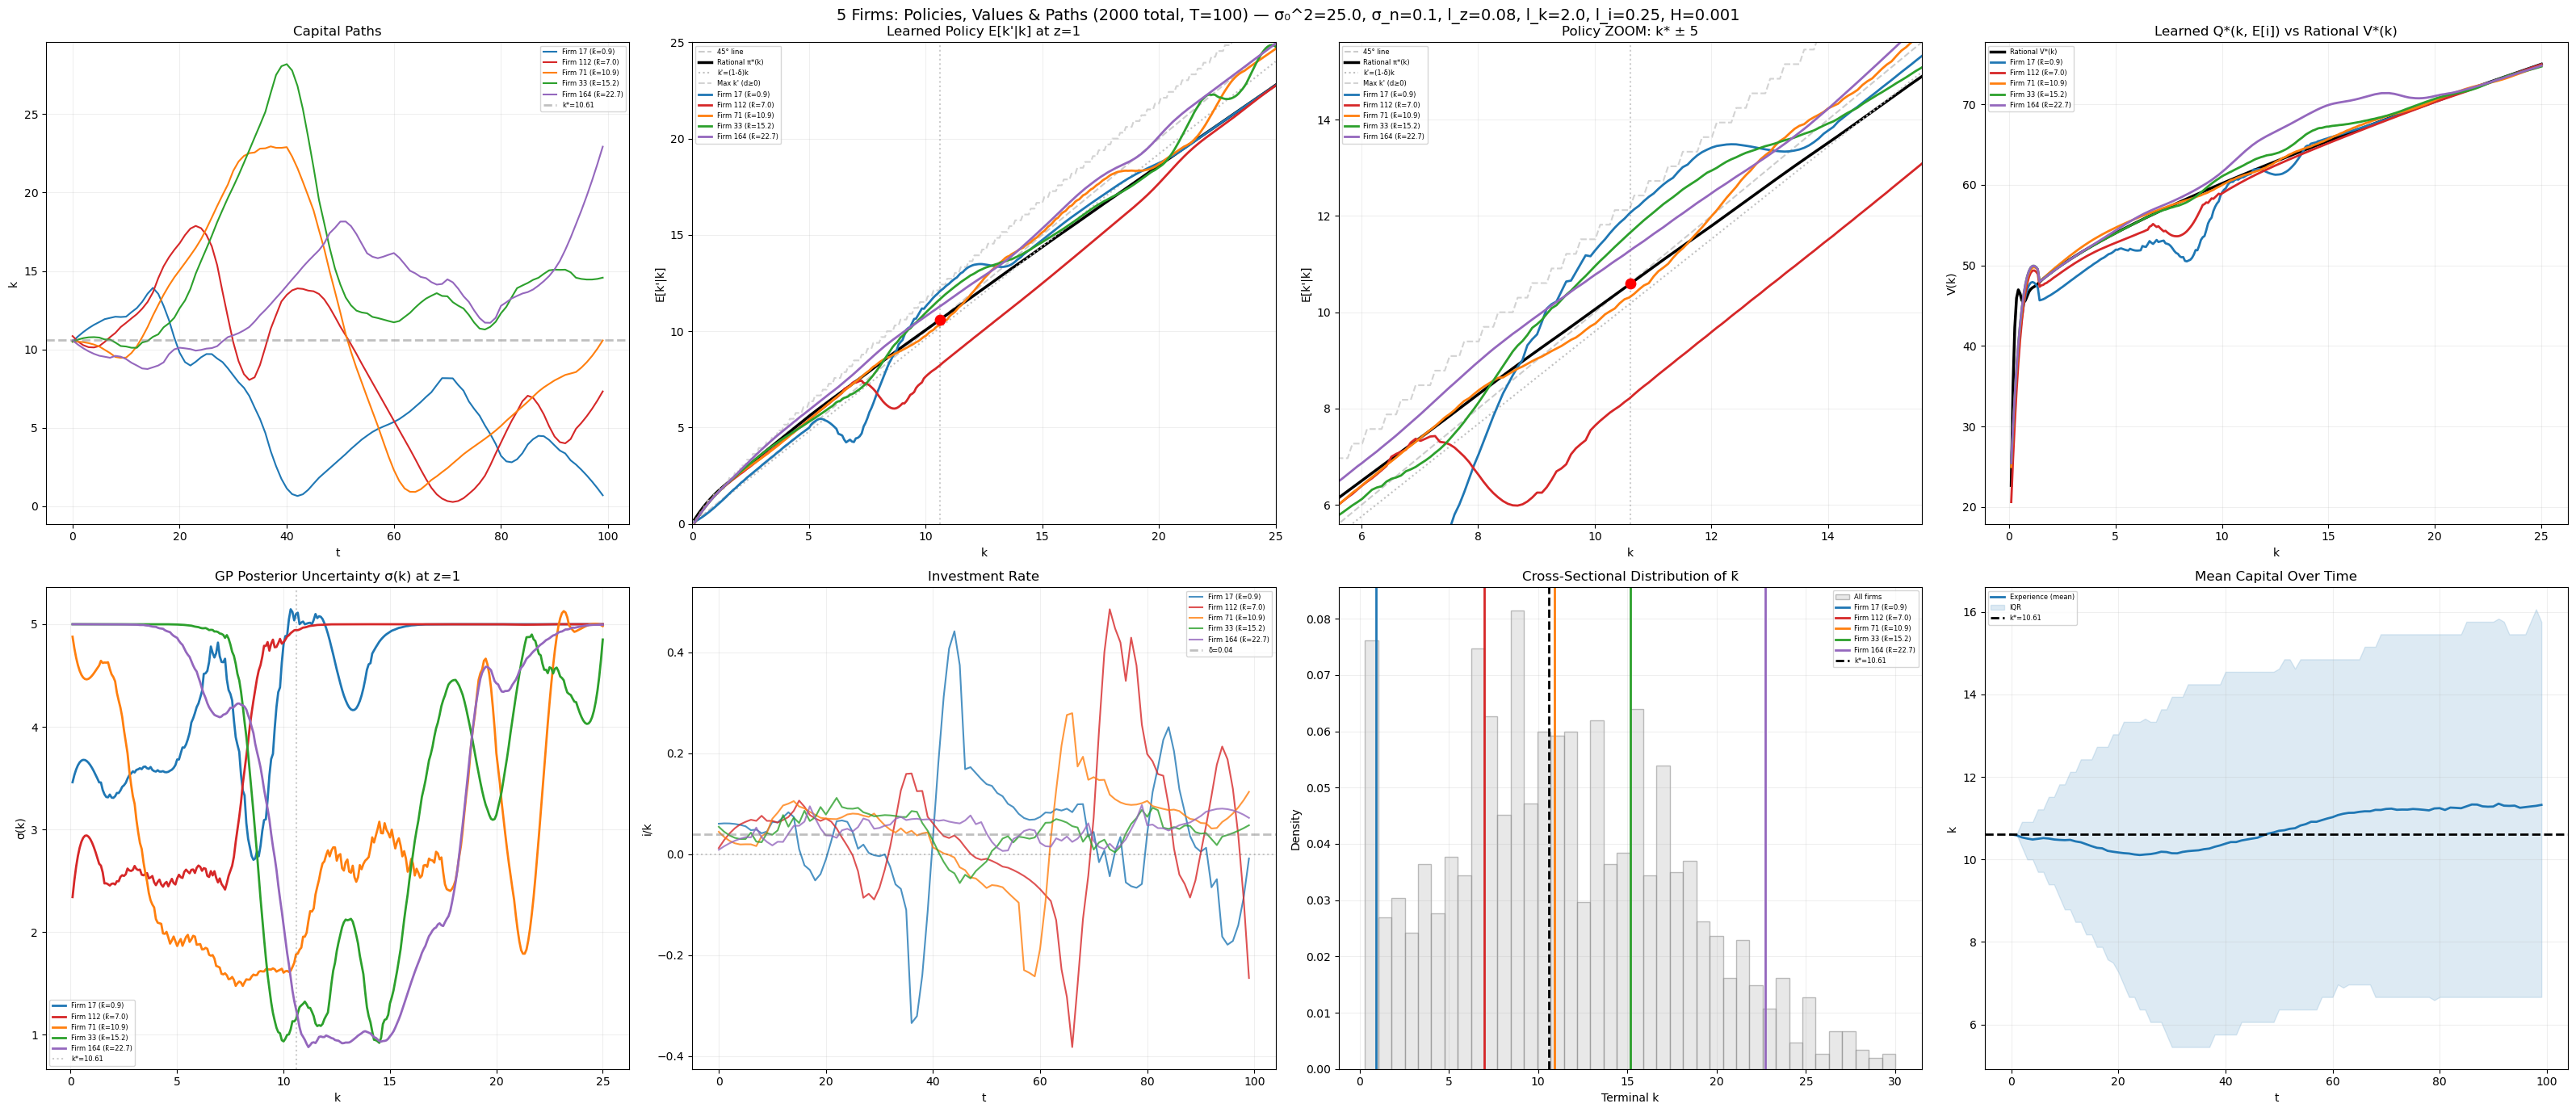

([<src.simulation.firm.ExperienceAgent at 0x15ddbd070>,
 [17, 112, 71, 33, 164])

In [ ]:
p = InvestmentParameters(KAPPA=2.0, SIGMA_EPS=0.05, RHO=0.9, DELTA=0.04,
                          R=0.01, N_z=5, BETA=0.97, THETA=0.3,
                          K_min=0.0, K_max=30)
env = InvestmentEnvironment(p, QuadraticAdjustmentCosts(p.KAPPA), seed=42)
rational_agent = RationalInvestmentAgent(env).fit()
k_ss = rational_agent.fixed_point()
b_ss = env.optimal_b_next(k_ss)

kernel = RBFKernel(sigma0=5.0, length_scales=[0.08, 2.0, 0.25])
gp_params = GPBeliefParameters(kernel=kernel, sigma_n=0.1)
true_value_prior = TrueValueFunctionPrior(rational_agent)
H_cal = 0.001

N_FIRMS = 2000
T = 100

K = np.zeros((N_FIRMS, T))
I = np.zeros((N_FIRMS, T))
D = np.zeros((N_FIRMS, T))
Z = np.zeros((N_FIRMS, T))
Q_CHOSEN = np.zeros((N_FIRMS, T))
K_RAT = np.zeros((N_FIRMS, T))
I_RAT = np.zeros((N_FIRMS, T))
D_RAT = np.zeros((N_FIRMS, T))
firm_agents = []

print(f"Simulating {N_FIRMS} firms x {T} periods")
print(f"k* = {k_ss:.4f}, b* = {b_ss:.4f}, H = {H_cal}")
print(f"GP: σ₀^2={gp_params.kernel.sigma0_sq}, σ_n={gp_params.sigma_n}, "
      f"l_k={gp_params.kernel.length_scales[1]}, l_i={gp_params.kernel.length_scales[2]}, l_z={gp_params.kernel.length_scales[0]}")

for j in range(N_FIRMS):
    if (j + 1) % 200 == 0:
        print(f"  Firm {j+1}/{N_FIRMS}...")

    gp_j = GPBelief(env_params=p, gp_params=gp_params, prior_mean_fn=true_value_prior)
    agent_j = ExperienceReasoningAgent(
        env=env, gp=gp_j,
        agent_params=InvestmentAgentParameters(H=H_cal),
        seed=j
    )
    shock_rng = np.random.default_rng(j)

    z_t, k_t, b_t = 1.0, k_ss, b_ss
    z_rat, k_rat, b_rat = 1.0, k_ss, b_ss

    for t in range(T):
        kp_exp, b_next_exp = agent_j.policy(z_t, k_t, b_t)
        i_t = kp_t - (1.0 - p.DELTA) * k_t
        d_t = env.dividend(z_t, k_t, i_t, b_t, b_next)
        gp_obs_t = env.gp_observation(z_t, k_t, i_t, b_next)
        q_t = agent_j.gp.predict(np.array([[z_t, k_t, i_t]]), return_std=False)[0]

        kp_rat, b_next_rat = rational_agent.policy(z_t, k_rat, b_rat)
        i_rat = kp_rat - (1.0 - p.DELTA) * k_rat
        d_rat = env.dividend(z_t, k_rat, i_rat, b_rat, b_next_rat)

        eps = shock_rng.normal(0.0, p.SIGMA_EPS)
        z_next = np.exp(p.RHO * np.log(max(z_t, 1e-12)) + eps)

        kp_greedy, _ = agent_j.get_greedy_action(z_next, kp_t, b_next)
        i_greedy = kp_greedy - (1.0 - p.DELTA) * kp_t
        agent_j.gp.add_observation(
            np.array([z_t, k_t, i_t]),
            np.array([z_next, kp_t, i_greedy]),
            gp_obs_t
        )

        Z[j, t] = z_t
        K[j, t] = k_t
        I[j, t] = i_t
        D[j, t] = d_t
        Q_CHOSEN[j, t] = q_t
        K_RAT[j, t] = k_rat
        I_RAT[j, t] = i_rat
        D_RAT[j, t] = d_rat

        z_t, k_t, b_t = z_next, kp_t, b_next
        z_rat, k_rat, b_rat = z_next, kp_rat, b_next_rat

    firm_agents.append(agent_j)

print("\n--- Done ---")
print(f"\nFinal period cross-section:")
print(f"  Experience K: mean={K[:,-1].mean():.2f}  median={np.median(K[:,-1]):.2f}  std={K[:,-1].std():.2f}")
print(f"  Rational  K: mean={K_RAT[:,-1].mean():.2f}  median={np.median(K_RAT[:,-1]):.2f}  std={K_RAT[:,-1].std():.2f}")
print(f"  Experience I: mean={I[:,-1].mean():.2f}  std={I[:,-1].std():.2f}")
print(f"  Rational  I: mean={I_RAT[:,-1].mean():.2f}  std={I_RAT[:,-1].std():.2f}")
print(f"  Frac firms at K_min: {(K[:,-1] <= p.K_min + 0.5).mean()*100:.1f}%")
print(f"  Mean |Δk| = {np.abs(K[:,-1] - K_RAT[:,-1]).mean():.2f}")

plot_firm_diagnostics(
    K, I, T, p, env, rational_agent, firm_agents, k_ss, b_ss,
    title_suffix=f"σ₀^2={gp_params.kernel.sigma0_sq}, σ_n={gp_params.sigma_n}, "
                 f"l_z={gp_params.kernel.length_scales[0]}, l_k={gp_params.kernel.length_scales[1]}, l_i={gp_params.kernel.length_scales[2]}, "
                 f"H={H_cal}"
)

## 2000 Firms Attempting to get Smoother policy functions while maintaining biases

In [ ]:
p = InvestmentParameters(KAPPA=2.0, SIGMA_EPS=0.05, RHO=0.9, DELTA=0.04,
                          R=0.01, N_z=5, BETA=0.97, THETA=0.3,
                          K_min=0.0, K_max=30)
env = InvestmentEnvironment(p, QuadraticAdjustmentCosts(p.KAPPA), seed=42)
rational_agent = RationalInvestmentAgent(env).fit()
k_ss = rational_agent.fixed_point()
b_ss = env.optimal_b_next(k_ss)


kernel = RBFKernel(sigma0=15.0, length_scales=[2.0, 10.0, 7.0])
gp_params = GPBeliefParameters(kernel=kernel, sigma_n=2.5)
true_value_prior = TrueValueFunctionPrior(rational_agent)
H_cal = calibrated_entropy_regularization_parameter(env, gp_params) # function to tune H

N_FIRMS = 2000
T = 100

K = np.zeros((N_FIRMS, T))
I = np.zeros((N_FIRMS, T))
D = np.zeros((N_FIRMS, T))
Z = np.zeros((N_FIRMS, T))
Q_CHOSEN = np.zeros((N_FIRMS, T))
K_RAT = np.zeros((N_FIRMS, T))
I_RAT = np.zeros((N_FIRMS, T))
D_RAT = np.zeros((N_FIRMS, T))
firm_agents = []

print(f"Simulating {N_FIRMS} firms x {T} periods")
print(f"k* = {k_ss:.4f}, b* = {b_ss:.4f}, H = {H_cal}")
print(f"GP: σ₀^2={gp_params.kernel.sigma0_sq}, σ_n={gp_params.sigma_n}, "
      f"l_k={gp_params.kernel.length_scales[1]}, l_i={gp_params.kernel.length_scales[2]}, l_z={gp_params.kernel.length_scales[0]}")

for j in range(N_FIRMS):
    if (j + 1) % 200 == 0:
        print(f"  Firm {j+1}/{N_FIRMS}...")

    gp_j = GPBelief(env_params=p, gp_params=gp_params, prior_mean_fn=true_value_prior)
    agent_j = ExperienceReasoningAgent(
        env=env, gp=gp_j,
        agent_params=InvestmentAgentParameters(H=H_cal),
        seed=j
    )
    shock_rng = np.random.default_rng(j)

    z_t, k_t, b_t = 1.0, k_ss, b_ss
    z_rat, k_rat, b_rat = 1.0, k_ss, b_ss

    for t in range(T):
        kp_exp, b_next_exp = agent_j.policy(z_t, k_t, b_t)
        i_t = kp_t - (1.0 - p.DELTA) * k_t
        d_t = env.dividend(z_t, k_t, i_t, b_t, b_next)
        gp_obs_t = env.gp_observation(z_t, k_t, i_t, b_next)
        q_t = agent_j.gp.predict(np.array([[z_t, k_t, i_t]]), return_std=False)[0]

        kp_rat, b_next_rat = rational_agent.policy(z_t, k_rat, b_rat)
        i_rat = kp_rat - (1.0 - p.DELTA) * k_rat
        d_rat = env.dividend(z_t, k_rat, i_rat, b_rat, b_next_rat)

        eps = shock_rng.normal(0.0, p.SIGMA_EPS)
        z_next = np.exp(p.RHO * np.log(max(z_t, 1e-12)) + eps)

        kp_greedy, _ = agent_j.get_greedy_action(z_next, kp_t, b_next)
        i_greedy = kp_greedy - (1.0 - p.DELTA) * kp_t
        agent_j.gp.add_observation(
            np.array([z_t, k_t, i_t]),
            np.array([z_next, kp_t, i_greedy]),
            gp_obs_t
        )

        Z[j, t] = z_t
        K[j, t] = k_t
        I[j, t] = i_t
        D[j, t] = d_t
        Q_CHOSEN[j, t] = q_t
        K_RAT[j, t] = k_rat
        I_RAT[j, t] = i_rat
        D_RAT[j, t] = d_rat

        z_t, k_t, b_t = z_next, kp_t, b_next
        z_rat, k_rat, b_rat = z_next, kp_rat, b_next_rat

    firm_agents.append(agent_j)

print("\n--- Done ---")
print(f"\nFinal period cross-section:")
print(f"  Experience K: mean={K[:,-1].mean():.2f}  median={np.median(K[:,-1]):.2f}  std={K[:,-1].std():.2f}")
print(f"  Rational  K: mean={K_RAT[:,-1].mean():.2f}  median={np.median(K_RAT[:,-1]):.2f}  std={K_RAT[:,-1].std():.2f}")
print(f"  Experience I: mean={I[:,-1].mean():.2f}  std={I[:,-1].std():.2f}")
print(f"  Rational  I: mean={I_RAT[:,-1].mean():.2f}  std={I_RAT[:,-1].std():.2f}")
print(f"  Frac firms at K_min: {(K[:,-1] <= p.K_min + 0.5).mean()*100:.1f}%")
print(f"  Mean |Δk| = {np.abs(K[:,-1] - K_RAT[:,-1]).mean():.2f}")

plot_firm_diagnostics(
    K, I, T, p, env, rational_agent, firm_agents, k_ss, b_ss,
    title_suffix=f"σ₀^2={gp_params.kernel.sigma0_sq}, σ_n={gp_params.sigma_n}, "
                 f"l_z={gp_params.kernel.length_scales[0]}, l_k={gp_params.kernel.length_scales[1]}, l_i={gp_params.kernel.length_scales[2]}, "
                 f"H={H_cal}",
    firm_ids=[500, 1000, 1500],
)

AttributeError: 'GPBeliefParameters' object has no attribute 'sigma0'

In [ ]:
import numpy as np
from scipy.interpolate import interp1d

# ── Setup ──
p = InvestmentParameters(KAPPA=2.0, SIGMA_EPS=0.025, RHO=0.8, 
                          DELTA=0.04, R=0.01, N_z=5, BETA=0.98, 
                          THETA=0.3, K_min=0.0, K_max=30)
env = InvestmentEnvironment(p, QuadraticAdjustmentCosts(p.KAPPA), seed=42)
rational_agent = RationalInvestmentAgent(env).fit()
k_ss = rational_agent.fixed_point()
b_ss = env.optimal_b_next(k_ss)

gp_params = GPBeliefParameters(sigma0=2.5, lz=1.0, lk=5.0, li=2.0, sigma_n=0.01)
true_value_prior = TrueValueFunctionPrior(rational_agent)
gp = GPBelief(env_params=p, gp_params=gp_params, prior_mean_fn=true_value_prior)
agent = ExperienceReasoningAgent(env=env, gp=gp, agent_params=InvestmentAgentParameters(H=0.0), seed=0)

iz_idx = int(np.argmin(np.abs(rational_agent.z_grid - 1.0)))
v_interp = interp1d(rational_agent.k_grid, rational_agent.v[iz_idx, :],
                     kind='cubic', fill_value='extrapolate')

# ── Pre-draw the shock sequence so both agents face identical z path ──
N_STEPS = 50
shock_rng = np.random.default_rng(0)
eps_seq = shock_rng.normal(0.0, p.SIGMA_EPS, size=N_STEPS) if p.SIGMA_EPS > 0 else np.zeros(N_STEPS)

# ── Initial conditions (identical) ──
z_t, k_t, b_t = 1.0, k_ss, b_ss           # experience agent
z_rat, k_rat, b_rat = 1.0, k_ss, b_ss      # rational agent

print(f"k* = {k_ss:.4f}")
print()
print(f"{'':=<150}")
print(f"{'t':>3} | {'z':>6} | "
      f"{'k_exp':>7} {'i_exp':>7} {'kp_exp':>7} {'d_exp':>7} | "
      f"{'k_rat':>7} {'i_rat':>7} {'kp_rat':>7} {'d_rat':>7} | "
      f"{'Δk':>7} {'Δi':>7} | "
      f"{'gp_Q':>9} {'true_Q':>9} {'gap':>7} {'TD_err':>8}")
print(f"{'':=<150}")

for t in range(N_STEPS):
    # ── Common z shock ──
    z_common = z_t  # both agents see same z

    # ── Experience agent ──
    (kp_exp, b_next_exp), delta_t = agent.policy(z_common, k_t, b_t, return_delta=True)
    i_exp = kp_exp - (1.0 - p.DELTA) * k_t
    d_exp = env.dividend(z_common, k_t, i_exp, b_t, b_next_exp)
    gp_obs_t = env.gp_observation(z_common, k_t, i_exp, b_next_exp)
    q_gp = agent.gp.predict(np.array([[z_common, k_t, i_exp]]), return_std=False)[0]
    true_q = gp_obs_t + p.BETA * float(v_interp(max(kp_exp, 1e-8)))

    # ── Rational agent (same z) ──
    kp_rat_val, b_next_rat = rational_agent.policy(z_common, k_rat, b_rat)
    i_rat = kp_rat_val - (1.0 - p.DELTA) * k_rat
    d_rat = env.dividend(z_common, k_rat, i_rat, b_rat, b_next_rat)

    # ── Next z (common shock) ──
    z_next = np.exp(p.RHO * np.log(max(z_common, 1e-12)) + eps_seq[t])

    # ── TD error ──
    kp_greedy_next, _ = agent.get_greedy_action(z_next, kp_exp, b_next_exp)
    i_greedy_next = kp_greedy_next - (1.0 - p.DELTA) * kp_exp
    q_next = agent.gp.predict(np.array([[z_next, kp_exp, i_greedy_next]]), return_std=False)[0]
    td_error = gp_obs_t + p.BETA * q_next - q_gp

    # ── Print ──
    dk = k_t - k_rat
    di = i_exp - i_rat
    print(f"{t+1:3d} | {z_common:6.3f} | "
          f"{k_t:7.2f} {i_exp:7.2f} {kp_exp:7.2f} {d_exp:7.2f} | "
          f"{k_rat:7.2f} {i_rat:7.2f} {kp_rat_val:7.2f} {d_rat:7.2f} | "
          f"{dk:7.2f} {di:7.2f} | "
          f"{q_gp:9.3f} {true_q:9.3f} {q_gp-true_q:7.3f} {td_error:8.4f}")

    # ── GP update ──
    agent.gp.add_observation(
        np.array([z_common, k_t, i_exp]),
        np.array([z_next, kp_exp, i_greedy_next]),
        gp_obs_t
    )

    # ── Advance both ──
    z_t, k_t, b_t = z_next, kp_exp, b_next_exp
    z_rat, k_rat, b_rat = z_next, kp_rat_val, b_next_rat

print(f"\n{'':=<150}")
print(f"SUMMARY at T={N_STEPS}:")
print(f"  Experience: k={k_t:.2f}  b={b_t:.2f}")
print(f"  Rational:   k={k_rat:.2f}  b={b_rat:.2f}")
print(f"  Gap:        Δk={k_t - k_rat:.2f}")

k* = 12.7271

  t |      z |   k_exp   i_exp  kp_exp   d_exp |   k_rat   i_rat  kp_rat   d_rat |      Δk      Δi |      gp_Q    true_Q     gap   TD_err
  1 |  1.000 |   12.73    0.51   12.73    1.75 |   12.73    0.51   12.73    1.75 |    0.00    0.00 |    91.376    91.376   0.000   0.0042
  2 |  1.003 |   12.73    0.51   12.73    1.75 |   12.73    0.51   12.73    1.75 |    0.00    0.00 |    91.579    91.383   0.196  -0.0086
  3 |  0.999 |   12.73    0.51   12.73    1.75 |   12.73    0.51   12.73    1.75 |    0.00    0.00 |    91.376    91.374   0.002   0.0198
  4 |  1.015 |   12.73    0.51   12.73    1.78 |   12.73    0.51   12.73    1.78 |    0.00    0.00 |    91.467    91.412   0.055   0.0309
  5 |  1.015 |   12.73    0.51   12.73    1.78 |   12.73    0.51   12.73    1.78 |    0.00    0.00 |    91.953    91.411   0.542   0.0026
  6 |  0.999 |   12.73    0.51   12.73    1.74 |   12.73    0.51   12.73    1.74 |    0.00    0.00 |    91.959    91.372   0.586  -0.0072
  7 |  1.008 |   12.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

def plot_firm_diagnostics(K, I, T, p, env, rational_agent, firm_agents, k_ss, b_ss, title_suffix=""):
    """
    Generates an 8-panel diagnostic dashboard. 
    Plots 5 individual firms (raw paths) AND overlays K-Means clustered averages.
    """
    fig, axes = plt.subplots(2, 4, figsize=(24, 12))
    fig.suptitle(f"Firm Investment Dynamics & Learned Policies\n{title_suffix}", fontsize=16)
    
    # ---------------------------------------------------------
    # 1. Setup & Pre-calculations
    # ---------------------------------------------------------
    np.random.seed(42)
    path_idx = np.random.choice(K.shape[0], 5, replace=False)
    colors_5 = plt.cm.tab10.colors[:5]
    
    # Capital grids for evaluation
    k_grid = np.linspace(max(0.1, p.K_min), 25.0, 50)
    k_grid_zoom = np.linspace(max(0.1, k_ss - 5), k_ss + 5, 50)
    
    # Rational Benchmark Evaluations
    rat_kp = np.zeros(len(k_grid))
    rat_v = np.zeros(len(k_grid))
    iz_1 = int(np.argmin(np.abs(rational_agent.z_grid - 1.0)))
    
    for i, kv in enumerate(k_grid):
        kp, _ = rational_agent.policy(1.0, kv, 0.0)
        rat_kp[i] = kp
        ik = int(np.argmin(np.abs(rational_agent.k_grid - kv)))
        rat_v[i] = rational_agent.v[iz_1, ik]

    # Evaluate all firms for clustering (sample 500 for speed)
    print("Evaluating policies for cluster analysis...")
    n_sample = min(500, len(firm_agents))
    sample_agents = np.random.choice(firm_agents, n_sample, replace=False)
    
    all_kp = np.zeros((n_sample, len(k_grid)))
    all_q = np.zeros((n_sample, len(k_grid)))
    all_std = np.zeros((n_sample, len(k_grid)))
    
    for j, agent in enumerate(sample_agents):
        for i, kv in enumerate(k_grid):
            kp, b_next = agent.get_expected_action(1.0, kv, 0.0)
            all_kp[j, i] = kp
            
            i_val = kp - (1.0 - p.DELTA) * kv
            q_mean, q_std = agent.gp.predict(np.array([[1.0, kv, i_val]]), return_std=True)
            all_q[j, i] = q_mean[0]
            all_std[j, i] = q_std[0]

    # Run K-Means Clustering on the Policy Curves
    n_clusters = 3
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(all_kp)
    cluster_colors = ['k', 'purple', 'brown'] # Distinct colors for the macro averages

    # Evaluate the 5 specific firms for the individual plots
    indiv_kp = np.zeros((5, len(k_grid)))
    indiv_q = np.zeros((5, len(k_grid)))
    indiv_std = np.zeros((5, len(k_grid)))
    
    for j, idx in enumerate(path_idx):
        agent = firm_agents[idx]
        for i, kv in enumerate(k_grid):
            kp, _ = agent.get_expected_action(1.0, kv, 0.0)
            indiv_kp[j, i] = kp
            i_val = kp - (1.0 - p.DELTA) * kv
            q_mean, q_std = agent.gp.predict(np.array([[1.0, kv, i_val]]), return_std=True)
            indiv_q[j, i] = q_mean[0]
            indiv_std[j, i] = q_std[0]

    # ---------------------------------------------------------
    # 2. Plotting Panels
    # ---------------------------------------------------------

    # [0, 0] Capital Paths over Time
    ax = axes[0, 0]
    for i, idx in enumerate(path_idx):
        ax.plot(K[idx, :], color=colors_5[i], alpha=0.8, label=f"Firm {idx}")
    ax.axhline(k_ss, color='gray', linestyle='--', alpha=0.7, label="Rational k*")
    ax.set_title("Capital Paths")
    ax.set_xlabel("t")
    ax.set_ylabel("k")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # [0, 1] Learned Policy E[k'|k]
    ax = axes[0, 1]
    ax.plot(k_grid, k_grid, color='gray', linestyle=':', label="45° Line")
    ax.plot(k_grid, rat_kp, color='black', linewidth=2.5, label="Rational Policy")
    
    # Plot Individual Firms (Thin/Squiggly)
    for i in range(5):
        ax.plot(k_grid, indiv_kp[i], color=colors_5[i], alpha=0.4, linewidth=1)
        
    # Plot Clustered Macro Averages (Thick/Smooth)
    for c in range(n_clusters):
        mask = (labels == c)
        ax.plot(k_grid, all_kp[mask].mean(axis=0), color=cluster_colors[c], linewidth=3, label=f"Cluster {c+1} Avg (N={mask.sum()})")

    ax.scatter([k_ss], [k_ss], color='red', zorder=5)
    ax.set_title("Learned Policy E[k'|k] at z=1")
    ax.set_xlabel("k")
    ax.set_ylabel("k'")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # [0, 2] Policy ZOOM
    ax = axes[0, 2]
    ax.plot(k_grid, k_grid, color='gray', linestyle=':')
    ax.plot(k_grid, rat_kp, color='black', linewidth=2.5)
    
    for i in range(5):
        ax.plot(k_grid, indiv_kp[i], color=colors_5[i], alpha=0.4, linewidth=1)
    for c in range(n_clusters):
        mask = (labels == c)
        ax.plot(k_grid, all_kp[mask].mean(axis=0), color=cluster_colors[c], linewidth=3)
        
    ax.scatter([k_ss], [k_ss], color='red', zorder=5)
    ax.set_xlim(max(0.1, k_ss - 5), k_ss + 5)
    ax.set_ylim(max(0.1, k_ss - 5), k_ss + 5)
    ax.set_title(f"Policy ZOOM: k* ± 5")
    ax.set_xlabel("k")
    ax.set_ylabel("k'")
    ax.grid(alpha=0.3)

    # [0, 3] Learned Q*(k, E[i]) vs Rational V*(k)
    ax = axes[0, 3]
    ax.plot(k_grid, rat_v, color='black', linewidth=2.5, label="Rational V*(k)")
    for i in range(5):
        ax.plot(k_grid, indiv_q[i], color=colors_5[i], alpha=0.4, linewidth=1)
    for c in range(n_clusters):
        mask = (labels == c)
        ax.plot(k_grid, all_q[mask].mean(axis=0), color=cluster_colors[c], linewidth=3, label=f"Cluster {c+1} Avg Q")
        
    ax.set_title("Learned Q*(k) vs Rational V*(k)")
    ax.set_xlabel("k")
    ax.set_ylabel("Value")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # [1, 0] GP Posterior Uncertainty
    ax = axes[1, 0]
    for i in range(5):
        ax.plot(k_grid, indiv_std[i], color=colors_5[i], alpha=0.4, linewidth=1)
    for c in range(n_clusters):
        mask = (labels == c)
        ax.plot(k_grid, all_std[mask].mean(axis=0), color=cluster_colors[c], linewidth=3, label=f"Cluster {c+1} Avg σ")
        
    ax.set_title("GP Posterior Uncertainty σ(k) at z=1")
    ax.set_xlabel("k")
    ax.set_ylabel("σ(k)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # [1, 1] Investment Rate
    ax = axes[1, 1]
    for i, idx in enumerate(path_idx):
        inv_rate = I[idx, :] / np.maximum(K[idx, :], 1e-8)
        ax.plot(inv_rate, color=colors_5[i], alpha=0.8)
    ax.axhline(p.DELTA, color='gray', linestyle='--', alpha=0.7, label="Steady State (δ)")
    ax.set_title("Investment Rate (i/k)")
    ax.set_xlabel("t")
    ax.set_ylabel("i/k")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # [1, 2] Cross-Sectional Distribution of Final Capital
    ax = axes[1, 2]
    final_K = K[:, -1]
    ax.hist(final_K, bins=40, density=True, color='lightgray', edgecolor='white', alpha=0.7)
    
    # Add lines for where the 5 sample firms ended up
    for i, idx in enumerate(path_idx):
        ax.axvline(final_K[idx], color=colors_5[i], linewidth=2, alpha=0.8, label=f"Firm {idx} Final")
        
    ax.axvline(k_ss, color='black', linestyle='--', linewidth=2, label="Rational k*")
    ax.set_title("Cross-Sectional Distribution of Final Capital")
    ax.set_xlabel("Final Capital (k_T)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # [1, 3] Mean Capital Over Time
    ax = axes[1, 3]
    mean_K = K.mean(axis=0)
    std_K = K.std(axis=0)
    t_arr = np.arange(T)
    
    ax.plot(t_arr, mean_K, color='#1f77b4', linewidth=2, label="Mean k (All Firms)")
    ax.fill_between(t_arr, mean_K - std_K, mean_K + std_K, color='#1f77b4', alpha=0.2)
    ax.axhline(k_ss, color='black', linestyle='--', linewidth=2, label="Rational k*")
    
    ax.set_title("Aggregate Mean Capital Over Time")
    ax.set_xlabel("t")
    ax.set_ylabel("Aggregate k")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

Simulating 2000 firms x 100 periods
k* = 10.6059, b* = 3.1818, H = 0.001
GP: Laplacian Kernel, σ₀^2=25.0, σ_n=0.4, l_k=4.0, l_i=1.5, l_z=0.08
  Firm 200/2000...
  Firm 400/2000...
  Firm 600/2000...
  Firm 800/2000...
  Firm 1000/2000...
  Firm 1200/2000...
  Firm 1400/2000...
  Firm 1600/2000...
  Firm 1800/2000...
  Firm 2000/2000...

--- Done Simulating ---

Final period cross-section:
  Experience K: mean=13.26  median=13.03  std=5.61
  Rational  K: mean=10.49  median=10.40  std=0.93

Extracting and clustering learned policies...


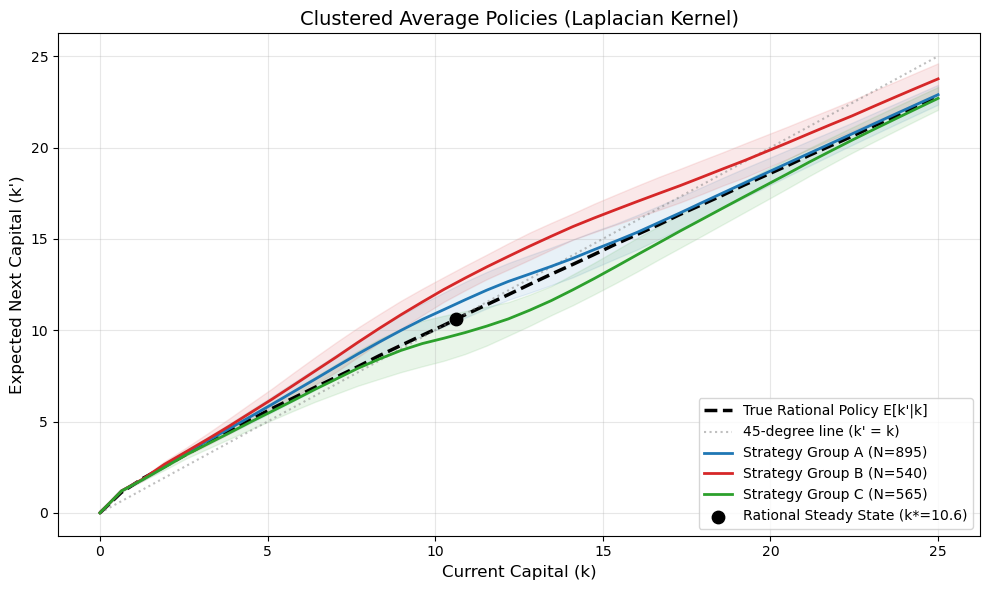

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

p = InvestmentParameters(
    KAPPA=2.0, SIGMA_EPS=0.05, RHO=0.9, DELTA=0.04,
    R=0.01, N_z=5, BETA=0.97, THETA=0.3,
    K_min=0.0, K_max=30
)
env = InvestmentEnvironment(p, QuadraticAdjustmentCosts(p.KAPPA), seed=42)
rational_agent = RationalInvestmentAgent(env).fit()
k_ss = rational_agent.fixed_point()
b_ss = env.optimal_b_next(k_ss)

kernel = LaplacianKernel(sigma0=5.0, length_scales=[0.08, 4.0, 1.5]) 
gp_params = GPBeliefParameters(kernel=kernel, sigma_n=0.4)           
true_value_prior = TrueValueFunctionPrior(rational_agent)
H_cal = 0.001

N_FIRMS = 2000
T = 100

K = np.zeros((N_FIRMS, T))
I = np.zeros((N_FIRMS, T))
D = np.zeros((N_FIRMS, T))
Z = np.zeros((N_FIRMS, T))
Q_CHOSEN = np.zeros((N_FIRMS, T))
K_RAT = np.zeros((N_FIRMS, T))
I_RAT = np.zeros((N_FIRMS, T))
D_RAT = np.zeros((N_FIRMS, T))
firm_agents = []

print(f"Simulating {N_FIRMS} firms x {T} periods")
print(f"k* = {k_ss:.4f}, b* = {b_ss:.4f}, H = {H_cal}")
print(f"GP: Laplacian Kernel, σ₀^2={gp_params.kernel.sigma0_sq}, σ_n={gp_params.sigma_n}, "
      f"l_k={gp_params.kernel.length_scales[1]}, l_i={gp_params.kernel.length_scales[2]}, l_z={gp_params.kernel.length_scales[0]}")

# --- Main Simulation Loop ---
for j in range(N_FIRMS):
    if (j + 1) % 200 == 0:
        print(f"  Firm {j+1}/{N_FIRMS}...")

    gp_j = GPBelief(env_params=p, gp_params=gp_params, prior_mean_fn=true_value_prior)
    agent_j = ExperienceReasoningAgent(
        env=env, gp=gp_j,
        agent_params=InvestmentAgentParameters(H=H_cal),
        seed=j
    )
    shock_rng = np.random.default_rng(j)

    z_t, k_t, b_t = 1.0, k_ss, b_ss
    z_rat, k_rat, b_rat = 1.0, k_ss, b_ss

    for t in range(T):
        (kp_t, b_next), _ = agent_j.policy(z_t, k_t, b_t, return_delta=True)
        i_t = kp_t - (1.0 - p.DELTA) * k_t
        d_t = env.dividend(z_t, k_t, i_t, b_t, b_next)
        gp_obs_t = env.gp_observation(z_t, k_t, i_t, b_next)
        q_t = agent_j.gp.predict(np.array([[z_t, k_t, i_t]]), return_std=False)[0]

        kp_rat, b_next_rat = rational_agent.policy(z_t, k_rat, b_rat)
        i_rat = kp_rat - (1.0 - p.DELTA) * k_rat
        d_rat = env.dividend(z_t, k_rat, i_rat, b_rat, b_next_rat)

        eps = shock_rng.normal(0.0, p.SIGMA_EPS)
        z_next = np.exp(p.RHO * np.log(max(z_t, 1e-12)) + eps)

        kp_greedy, _ = agent_j.get_greedy_action(z_next, kp_t, b_next)
        i_greedy = kp_greedy - (1.0 - p.DELTA) * kp_t
        agent_j.gp.add_observation(
            np.array([z_t, k_t, i_t]),
            np.array([z_next, kp_t, i_greedy]),
            gp_obs_t
        )

        Z[j, t] = z_t
        K[j, t] = k_t
        I[j, t] = i_t
        D[j, t] = d_t
        Q_CHOSEN[j, t] = q_t
        K_RAT[j, t] = k_rat
        I_RAT[j, t] = i_rat
        D_RAT[j, t] = d_rat

        z_t, k_t, b_t = z_next, kp_t, b_next
        z_rat, k_rat, b_rat = z_next, kp_rat, b_next_rat

    firm_agents.append(agent_j)

print("\n--- Done Simulating ---")
print(f"\nFinal period cross-section:")
print(f"  Experience K: mean={K[:,-1].mean():.2f}  median={np.median(K[:,-1]):.2f}  std={K[:,-1].std():.2f}")
print(f"  Rational  K: mean={K_RAT[:,-1].mean():.2f}  median={np.median(K_RAT[:,-1]):.2f}  std={K_RAT[:,-1].std():.2f}")

# ---------------------------------------------------------
# SMART AVERAGING: Cluster Firms by Learned Policy
# ---------------------------------------------------------
print("\nExtracting and clustering learned policies...")
eval_k_grid = np.linspace(p.K_min, 25.0, 40)
firm_policies = np.zeros((N_FIRMS, len(eval_k_grid)))

# 1. Evaluate every firm's final expected policy at z=1.0
for j, agent in enumerate(firm_agents):
    for i_k, k_val in enumerate(eval_k_grid):
        kp, _ = agent.get_expected_action(z=1.0, k=k_val, b=0.0)
        firm_policies[j, i_k] = kp

# 2. Cluster the policies into 3 behavioral groups
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(firm_policies)

# 3. Calculate the True Rational Policy for comparison
rational_policy = np.array([rational_agent.policy(1.0, k, 0.0)[0] for k in eval_k_grid])

# 4. Plot the Smart Averages
plt.figure(figsize=(10, 6))
plt.plot(eval_k_grid, rational_policy, 'k--', linewidth=2.5, label="True Rational Policy E[k'|k]")
plt.plot(eval_k_grid, eval_k_grid, color='gray', alpha=0.5, linestyle=':', label="45-degree line (k' = k)")

colors = ['#1f77b4', '#d62728', '#2ca02c']
cluster_names = ["Strategy Group A", "Strategy Group B", "Strategy Group C"]

for c in range(n_clusters):
    cluster_mask = (cluster_labels == c)
    n_in_cluster = cluster_mask.sum()
    
    # Average the policy curves for all firms in this cluster
    avg_policy = firm_policies[cluster_mask].mean(axis=0)
    
    # Calculate standard deviation band for this cluster
    std_policy = firm_policies[cluster_mask].std(axis=0)
    
    plt.plot(eval_k_grid, avg_policy, color=colors[c], linewidth=2, 
             label=f"{cluster_names[c]} (N={n_in_cluster})")
    plt.fill_between(eval_k_grid, avg_policy - std_policy, avg_policy + std_policy, 
                     color=colors[c], alpha=0.1)

plt.scatter([k_ss], [k_ss], color='black', zorder=5, s=80, label=f"Rational Steady State (k*={k_ss:.1f})")

plt.title("Clustered Average Policies (Laplacian Kernel)", fontsize=14)
plt.xlabel("Current Capital (k)", fontsize=12)
plt.ylabel("Expected Next Capital (k')", fontsize=12)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Evaluating policies for cluster analysis...


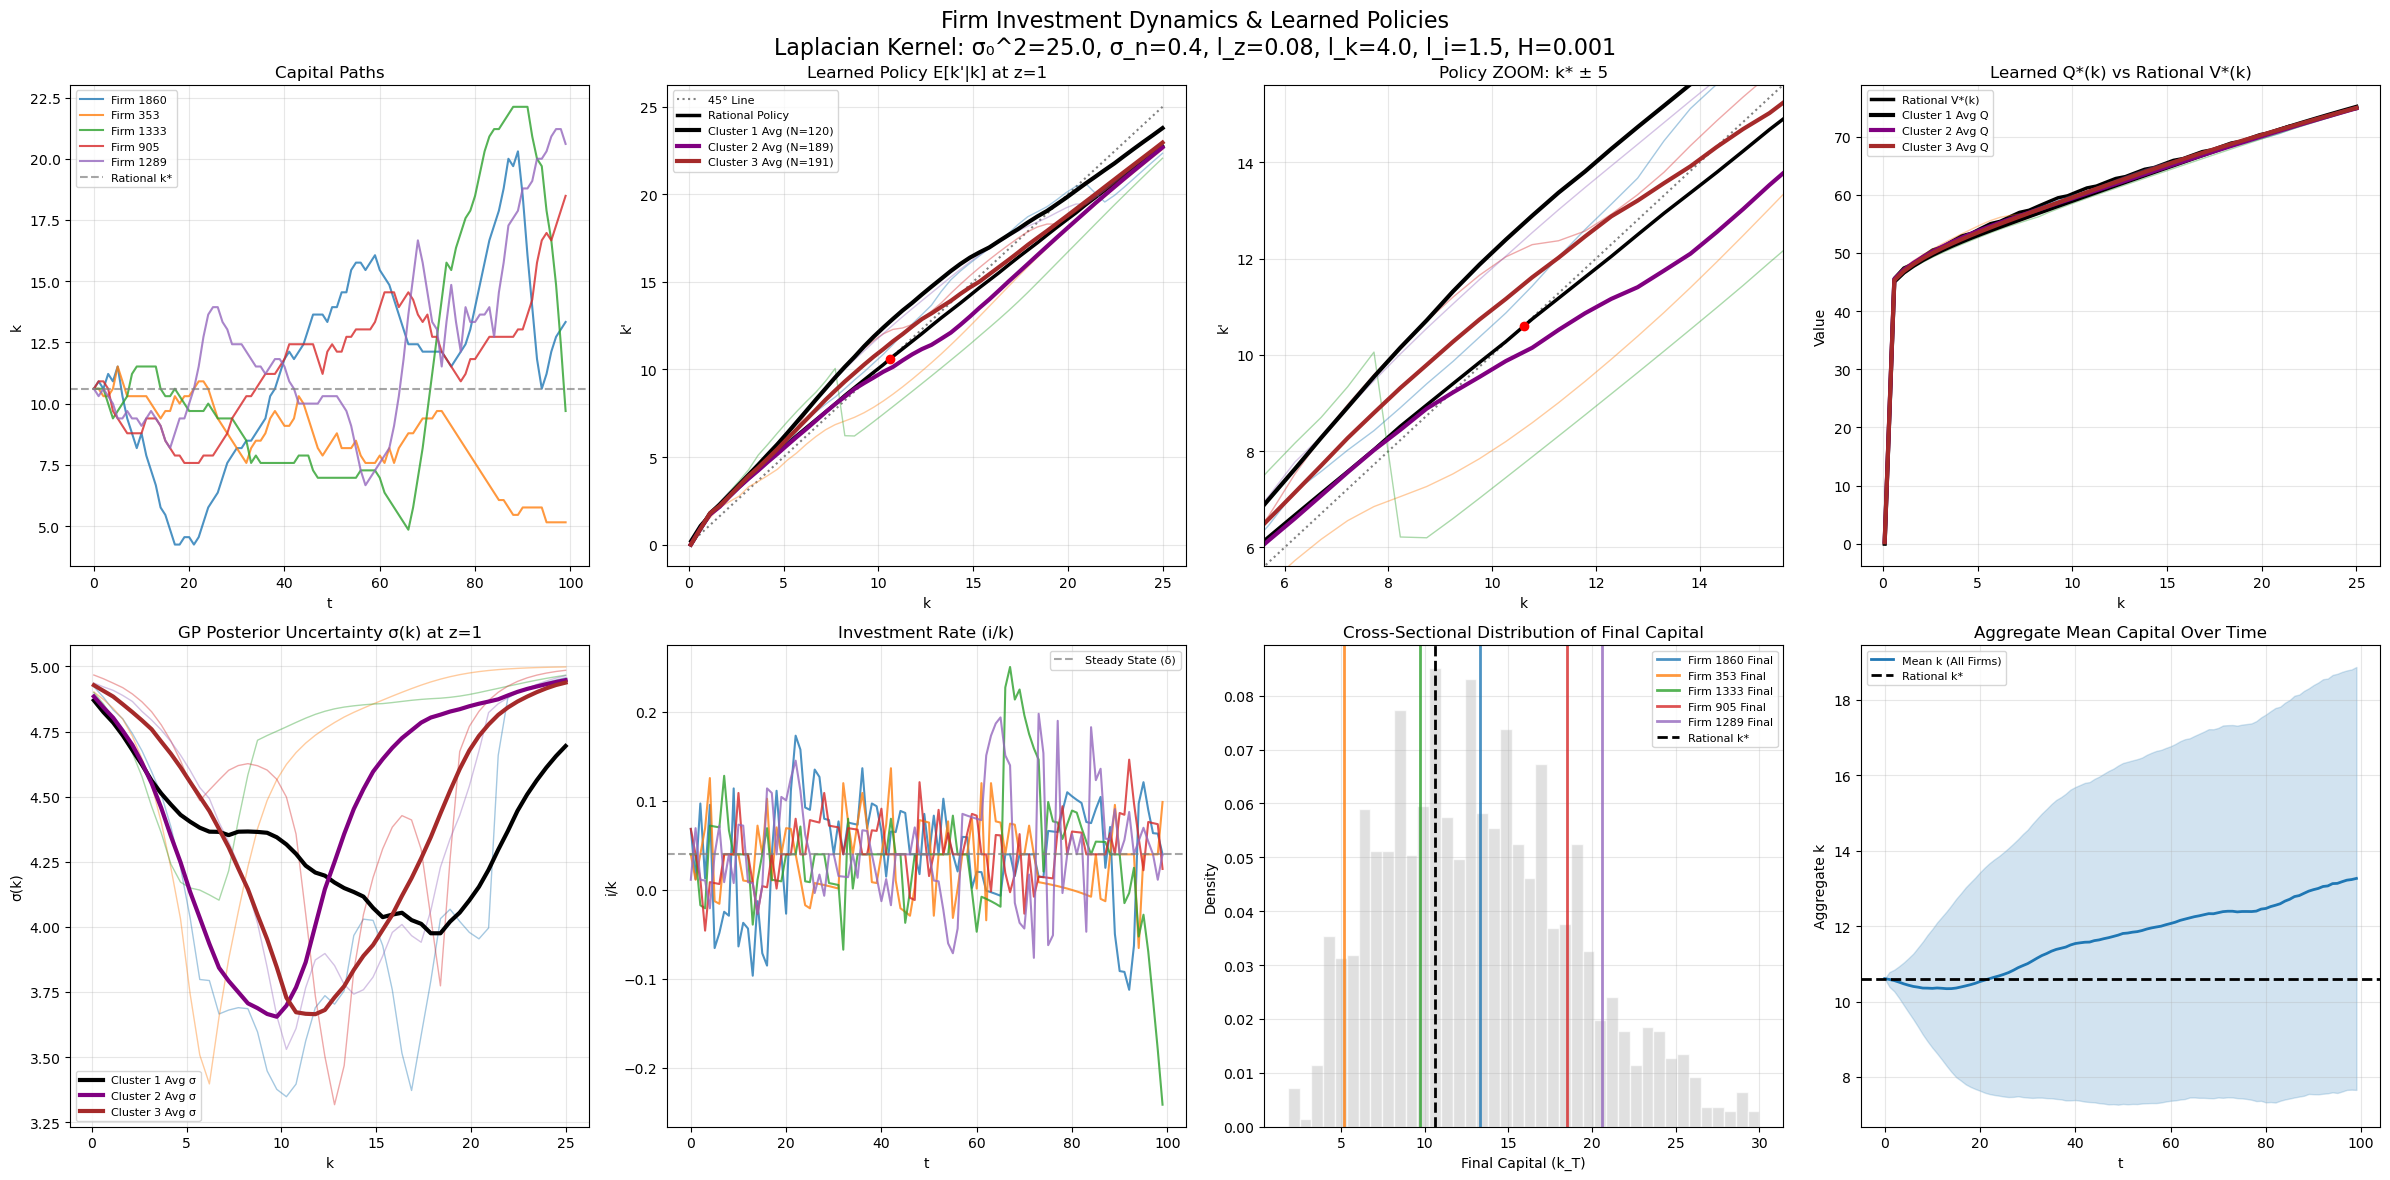

In [7]:
plot_firm_diagnostics(
    K, I, T, p, env, rational_agent, firm_agents, k_ss, b_ss,
    title_suffix=f"Laplacian Kernel: σ₀^2={gp_params.kernel.sigma0_sq}, σ_n={gp_params.sigma_n}, "
                 f"l_z={gp_params.kernel.length_scales[0]}, l_k={gp_params.kernel.length_scales[1]}, l_i={gp_params.kernel.length_scales[2]}, "
                 f"H={H_cal}"
)

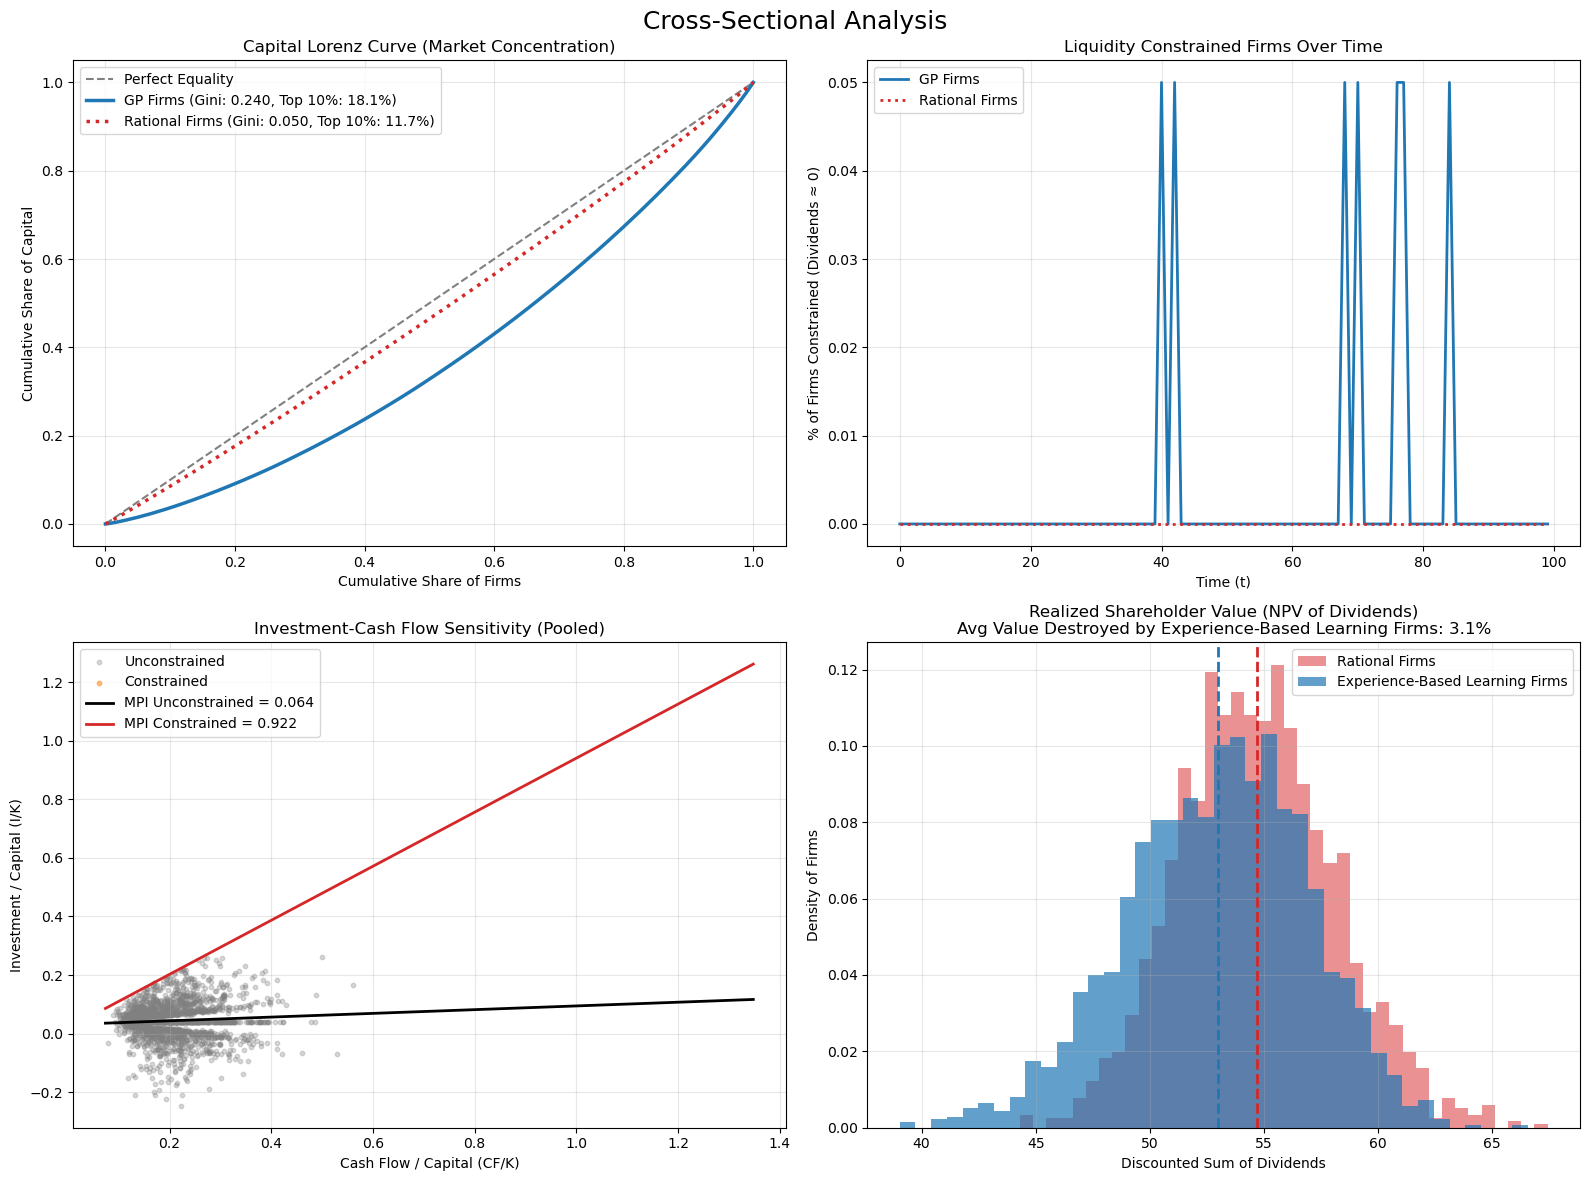

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def gini_coefficient(array):
    """Calculate the Gini coefficient of a numpy array."""
    array = np.sort(np.array(array).flatten())

    if array.min() < 0:
        array = array - array.min()
    array = array + 1e-8
    n = len(array)
    index = np.arange(1, n + 1)
    return ((np.sum((2 * index - n  - 1) * array)) / (n * np.sum(array)))

def plot_macro_cross_section(K, I, D, Z, K_RAT, D_RAT, p):

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle("Cross-Sectional Analysis", fontsize=18)
    
    # Market concentration
    ax = axes[0, 0]
    final_K = K[:, -1]
    final_K_rat = K_RAT[:, -1]
    
    # Calculate Lorenz Curves
    def lorenz(arr):
        sorted_arr = np.sort(arr)
        lorenz_curve = np.cumsum(sorted_arr) / np.sum(sorted_arr)
        return np.insert(lorenz_curve, 0, 0)
    
    l_gp = lorenz(final_K)
    l_rat = lorenz(final_K_rat)
    x_lorenz = np.linspace(0, 1, len(l_gp))
    
    gini_gp = gini_coefficient(final_K)
    gini_rat = gini_coefficient(final_K_rat)
    
    top_10_share_gp = np.sum(np.sort(final_K)[-int(len(final_K)*0.1):]) / np.sum(final_K)
    top_10_share_rat = np.sum(np.sort(final_K_rat)[-int(len(final_K_rat)*0.1):]) / np.sum(final_K_rat)

    ax.plot(x_lorenz, x_lorenz, color='gray', linestyle='--', label="Perfect Equality")
    ax.plot(x_lorenz, l_gp, color='#1f77b4', linewidth=2.5, 
            label=f"GP Firms (Gini: {gini_gp:.3f}, Top 10%: {top_10_share_gp*100:.1f}%)")
    ax.plot(x_lorenz, l_rat, color='#d62728', linewidth=2.5, linestyle=':', 
            label=f"Rational Firms (Gini: {gini_rat:.3f}, Top 10%: {top_10_share_rat*100:.1f}%)")
    
    ax.set_title("Capital Lorenz Curve (Market Concentration)")
    ax.set_xlabel("Cumulative Share of Firms")
    ax.set_ylabel("Cumulative Share of Capital")
    ax.legend(loc="upper left")
    ax.grid(alpha=0.3)

    # Financial Constraints (The "Hand-to-Mouth" Equivalent)
    ax = axes[0, 1]
    # A firm is financially constrained if it pays ~0 dividends (it reinvests every penny it can borrow)
    constrained_threshold = 1e-3
    frac_constrained_gp = np.mean(D < constrained_threshold, axis=0) * 100
    frac_constrained_rat = np.mean(D_RAT < constrained_threshold, axis=0) * 100
    
    time_axis = np.arange(K.shape[1])
    ax.plot(time_axis, frac_constrained_gp, color='#1f77b4', linewidth=2, label="GP Firms")
    ax.plot(time_axis, frac_constrained_rat, color='#d62728', linewidth=2, linestyle=':', label="Rational Firms")
    
    ax.set_title("Liquidity Constrained Firms Over Time")
    ax.set_xlabel("Time (t)")
    ax.set_ylabel("% of Firms Constrained (Dividends ≈ 0)")
    ax.legend()
    ax.grid(alpha=0.3)

    # 3. Investment-Cash Flow Sensitivity (The "MPC" Equivalent)
    ax = axes[1, 0]
    # Calculate Cash Flow = z * k^alpha
    CF = Z * (K ** p.ALPHA)
    
    # Flatten the arrays to run a pooled regression across all firms and time
    # (Exclude first 25 periods to allow for burn-in)
    i_k = (I[:, 25:] / K[:, 25:]).flatten()
    cf_k = (CF[:, 25:] / K[:, 25:]).flatten()
    is_constrained = (D[:, 25:] < constrained_threshold).flatten()
    
    # Sub-sample for scatter plot clarity
    sample_idx = np.random.choice(len(i_k), 2000, replace=False)
    
    ax.scatter(cf_k[sample_idx][~is_constrained[sample_idx]], i_k[sample_idx][~is_constrained[sample_idx]], 
               color='gray', alpha=0.3, s=10, label="Unconstrained")
    ax.scatter(cf_k[sample_idx][is_constrained[sample_idx]], i_k[sample_idx][is_constrained[sample_idx]], 
               color='#ff7f0e', alpha=0.5, s=10, label="Constrained")
    
    # Regression lines (MPI: Marginal Propensity to Invest)
    slope_uncon, intercept_uncon, _, _, _ = stats.linregress(cf_k[~is_constrained], i_k[~is_constrained])
    slope_con, intercept_con, _, _, _ = stats.linregress(cf_k[is_constrained], i_k[is_constrained])
    
    x_vals = np.linspace(cf_k.min(), cf_k.max(), 100)
    ax.plot(x_vals, intercept_uncon + slope_uncon * x_vals, color='black', linewidth=2, 
            label=f"MPI Unconstrained = {slope_uncon:.3f}")
    ax.plot(x_vals, intercept_con + slope_con * x_vals, color='#d62728', linewidth=2, 
            label=f"MPI Constrained = {slope_con:.3f}")
    
    ax.set_title("Investment-Cash Flow Sensitivity (Pooled)")
    ax.set_xlabel("Cash Flow / Capital (CF/K)")
    ax.set_ylabel("Investment / Capital (I/K)")
    ax.legend()
    ax.grid(alpha=0.3)

    # Shareholder Value Destruction (Welfare / NPV)
    ax = axes[1, 1]
    # Calculate the Net Present Value of all realized dividends for each firm
    discount_factors = p.BETA ** np.arange(K.shape[1])
    
    npv_gp = np.sum(D * discount_factors, axis=1)
    npv_rat = np.sum(D_RAT * discount_factors, axis=1)
    
    # How much value did bounded rationality destroy on average?
    value_destruction = 1 - (np.mean(npv_gp) / np.mean(npv_rat))
    
    ax.hist(npv_rat, bins=40, alpha=0.5, color='#d62728', label="Rational Firms", density=True)
    ax.hist(npv_gp, bins=40, alpha=0.7, color='#1f77b4', label="Experience-Based Learning Firms", density=True)
    
    ax.axvline(np.mean(npv_rat), color='#d62728', linestyle='dashed', linewidth=2)
    ax.axvline(np.mean(npv_gp), color='#1f77b4', linestyle='dashed', linewidth=2)
    
    ax.set_title(f"Realized Shareholder Value (NPV of Dividends)\nAvg Value Destroyed by Experience-Based Learning Firms: {value_destruction*100:.1f}%")
    ax.set_xlabel("Discounted Sum of Dividends")
    ax.set_ylabel("Density of Firms")
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# --- Run the function ---
plot_macro_cross_section(K, I, D, Z, K_RAT, D_RAT, p)

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

p = InvestmentParameters(
    KAPPA=2.0, SIGMA_EPS=0.05, RHO=0.9, DELTA=0.04,
    R=0.01, N_z=5, BETA=0.97, THETA=0.3,
    K_min=0.0, K_max=30
)
env = InvestmentEnvironment(p, QuadraticAdjustmentCosts(p.KAPPA), seed=42)
rational_agent = RationalInvestmentAgent(env).fit()
k_ss = rational_agent.fixed_point()
b_ss = env.optimal_b_next(k_ss)

kernel = LaplacianKernel(sigma0=5.0, length_scales=[0.08, 4.0, 1.5]) 
gp_params = GPBeliefParameters(kernel=kernel, sigma_n=0.4)           
true_value_prior = TrueValueFunctionPrior(rational_agent)
H_cal = 0.001

N_FIRMS = 1
T = 10

K = np.zeros((N_FIRMS, T))
I = np.zeros((N_FIRMS, T))
D = np.zeros((N_FIRMS, T))
Z = np.zeros((N_FIRMS, T))
Q_CHOSEN = np.zeros((N_FIRMS, T))
K_RAT = np.zeros((N_FIRMS, T))
I_RAT = np.zeros((N_FIRMS, T))
D_RAT = np.zeros((N_FIRMS, T))
firm_agents = []

print(f"Simulating {N_FIRMS} firms x {T} periods")
print(f"k* = {k_ss:.4f}, b* = {b_ss:.4f}, H = {H_cal}")
print(f"GP: Laplacian Kernel, σ₀^2={gp_params.kernel.sigma0_sq}, σ_n={gp_params.sigma_n}, "
      f"l_k={gp_params.kernel.length_scales[1]}, l_i={gp_params.kernel.length_scales[2]}, l_z={gp_params.kernel.length_scales[0]}")

# --- Main Simulation Loop ---
for j in range(N_FIRMS):
    if (j + 1) % 200 == 0:
        print(f"  Firm {j+1}/{N_FIRMS}...")

    gp_j = GPBelief(env_params=p, gp_params=gp_params, prior_mean_fn=true_value_prior)
    agent_j = ExperienceReasoningAgent(
        env=env, gp=gp_j,
        agent_params=InvestmentAgentParameters(H=H_cal),
        seed=j
    )
    shock_rng = np.random.default_rng(j)

    z_t, k_t, b_t = 1.0, k_ss, b_ss
    z_rat, k_rat, b_rat = 1.0, k_ss, b_ss

    for t in range(T):
        (kp_t, b_next), _ = agent_j.policy(z_t, k_t, b_t, return_delta=True)
        i_t = kp_t - (1.0 - p.DELTA) * k_t
        d_t = env.dividend(z_t, k_t, i_t, b_t, b_next)
        gp_obs_t = env.gp_observation(z_t, k_t, i_t, b_next)
        q_t = agent_j.gp.predict(np.array([[z_t, k_t, i_t]]), return_std=False)[0]

        kp_rat, b_next_rat = rational_agent.policy(z_t, k_rat, b_rat)
        i_rat = kp_rat - (1.0 - p.DELTA) * k_rat
        d_rat = env.dividend(z_t, k_rat, i_rat, b_rat, b_next_rat)

        eps = shock_rng.normal(0.0, p.SIGMA_EPS)
        z_next = np.exp(p.RHO * np.log(max(z_t, 1e-12)) + eps)

        kp_greedy, _ = agent_j.get_greedy_action(z_next, kp_t, b_next)
        i_greedy = kp_greedy - (1.0 - p.DELTA) * kp_t
        agent_j.gp.add_observation(
            np.array([z_t, k_t, i_t]),
            np.array([z_next, kp_t, i_greedy]),
            gp_obs_t
        )

        Z[j, t] = z_t
        K[j, t] = k_t
        I[j, t] = i_t
        D[j, t] = d_t
        Q_CHOSEN[j, t] = q_t
        K_RAT[j, t] = k_rat
        I_RAT[j, t] = i_rat
        D_RAT[j, t] = d_rat

        z_t, k_t, b_t = z_next, kp_t, b_next
        z_rat, k_rat, b_rat = z_next, kp_rat, b_next_rat

    firm_agents.append(agent_j)

print("\n--- Done Simulating ---")
print(f"\nFinal period cross-section:")
print(f"  Experience K: mean={K[:,-1].mean():.2f}  median={np.median(K[:,-1]):.2f}  std={K[:,-1].std():.2f}")
print(f"  Rational  K: mean={K_RAT[:,-1].mean():.2f}  median={np.median(K_RAT[:,-1]):.2f}  std={K_RAT[:,-1].std():.2f}")

Simulating 1 firms x 10 periods
k* = 10.6059, b* = 3.1818, H = 0.001
GP: Laplacian Kernel, σ₀^2=25.0, σ_n=0.4, l_k=4.0, l_i=1.5, l_z=0.08


TypeError: ExperienceReasoningAgent.policy() got an unexpected keyword argument 'return_delta'

In [33]:
agent = test_agents[0]

In [34]:
agent.gp

In [26]:
env_test.action_query_grid(1.0, 10.0).shape

(100, 3)

In [35]:
mu_E, Sigma_E = agent.gp.predict_full(env_test.action_query_grid(1.0, 10.0))

In [36]:
k_cands, X_q, mean, std_E = agent.get_beliefs(1, 10, 0)
_, delta_E = agent._entropy_policy(mean, std_E)

In [37]:
delta_E

0.010850186732383065

In [39]:
_, Sigma_E = agent.gp.predict_full(X_q)


In [40]:
vals_E, V = np.linalg.eigh(Sigma_E)

In [59]:
water_level = .000239 / (agent.agent_params.H * delta_E)

In [60]:
water_level

np.float64(215.2422473490279)

In [10]:
vals_E, V = np.linalg.eigh(Sigma_E)

In [61]:
vals_R = np.minimum(vals_E, water_level)

In [62]:
vals_R

array([201.27738096, 215.24224735, 215.24224735, 215.24224735,
       215.24224735, 215.24224735, 215.24224735, 215.24224735,
       215.24224735, 215.24224735, 215.24224735, 215.24224735,
       215.24224735, 215.24224735, 215.24224735, 215.24224735,
       215.24224735, 215.24224735, 215.24224735, 215.24224735,
       215.24224735, 215.24224735, 215.24224735, 215.24224735,
       215.24224735, 215.24224735, 215.24224735, 215.24224735,
       215.24224735, 215.24224735, 215.24224735, 215.24224735,
       215.24224735, 215.24224735, 215.24224735, 215.24224735,
       215.24224735, 215.24224735, 215.24224735, 215.24224735,
       215.24224735, 215.24224735, 215.24224735, 215.24224735,
       215.24224735, 215.24224735, 215.24224735])

In [63]:
Sigma_R = V @ np.diag(vals_R) @ V.T

In [64]:
Sigma_R

array([[ 2.15242247e+02,  5.15971913e-14,  1.57459599e-14, ...,
         1.23203927e-14, -3.50435786e-16, -6.05153046e-15],
       [ 4.83029982e-14,  2.15242247e+02, -1.77256531e-14, ...,
         7.22971361e-16, -7.98944915e-16, -7.09395329e-16],
       [ 1.42229854e-14, -1.76886356e-14,  2.15242247e+02, ...,
        -1.65053126e-14, -3.22994541e-16,  6.97149419e-15],
       ...,
       [ 1.24601348e-14,  7.27527187e-16, -1.67989003e-14, ...,
         2.15242247e+02,  4.16877957e-14, -4.23198711e-14],
       [-3.40993422e-16, -7.94518524e-16, -3.16832709e-16, ...,
         4.08367934e-14,  2.15242247e+02,  1.51088388e-13],
       [-7.06947927e-15, -7.03813699e-16,  8.15380516e-15, ...,
        -4.80265817e-14,  1.67116520e-13,  2.15242247e+02]])

In [65]:
np.sqrt(np.maximum(np.diag(Sigma_R), 0))

array([14.67113654, 14.67113654, 14.67113654, 14.67113654, 14.67113654,
       14.67113654, 14.67113654, 14.67113654, 14.67113654, 14.67113654,
       14.67113654, 14.67113654, 14.67113654, 14.67113654, 14.67113654,
       14.67113654, 14.67113654, 14.67113654, 14.67113654, 14.67113654,
       14.67113654, 14.67113654, 14.67113654, 14.67113654, 14.67113654,
       14.67113654, 14.67113654, 14.67113654, 14.67113654, 14.67113654,
       14.67113654, 14.67113654, 14.67113613, 14.18722668, 14.67113627,
       14.67113654, 14.67113654, 14.67113654, 14.67113654, 14.67113654,
       14.67113654, 14.67113654, 14.67113654, 14.67113654, 14.67113654,
       14.67113654, 14.67113654])